In [176]:
import random
import dotenv
import pathlib
import os
random.seed(2024)
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")  # directs to gpfs in scratch
from ctd.task_modeling.task_env.task_env import PClicks
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import pickle
import os
import pickle
from pathlib import Path
from matplotlib import cm

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import torch
from DSA.stats import dsa_bw_data_splits, dsa_to_id
from sklearn.decomposition import PCA
from scipy.linalg import svd
from matplotlib.colors import LogNorm

from ctd.comparison.analysis.analysis import Analysis
from ctd.task_modeling.model.rnn import FullRankRNNCell, LowRankRNNCell
from ctd.comparison.fixedpoints import find_fixed_points
from ctd.task_modeling.task_env.task_env import DecoupledEnvironment

In [184]:
    def plot_flow_field_new(self, latents_range: list, num_points: int, inputs_latents: np.array, input_field: np.array,  
                    input_latents_extra: np.array=None, custom_n_timesteps: int=None, n_trials=10, 
                    scatter_trajectories=False, xstar=None, is_stable=None,  plot_wrapper_trajs=False, 
                    filter_pc_rate:int=None, avg_per_rate=False, lint_plot_style=False, 
                    cmap_field=plt.get_cmap('pink'), cmap_time=plt.get_cmap('copper'), cmap_rate=plt.get_cmap('coolwarm'),
                    ics_noise=None, pca=True, koopman=False, phase='all', ortho_koopman=False, timescales=None, 
                    cluster_centers=None, cluster_is_stable=None, t_min=5.0, t_max=10.0,timescale_cmap=plt.get_cmap('cool'), 
                    pca_obj=None, field_color_only=False, **kwargs):

        if hasattr(self.wrapper.model, "generator"):
            model = self.wrapper.model.generator
        elif hasattr(self.wrapper.model, "cell"):
            model = self.wrapper.model.cell
        else:
            raise ValueError("No generator or cell found in model")
        
        # input shape should match n_dimension
        tt_ics, correct_inputs, _ = self.get_model_inputs(phase='all')
        if inputs_latents.shape[-1] != correct_inputs.shape[-1]: 
            raise ValueError("inputs_latents should have last dimension: ", correct_inputs.shape[-1])
        elif input_field.shape[0] != correct_inputs.shape[-1]:
            raise ValueError("input_field should have last dimension: ", correct_inputs.shape[-1])
        else:
            inputs_latents = torch.tensor(inputs_latents, dtype=torch.float32)  #from numpy to tensor
            input_field = torch.tensor(input_field, dtype=torch.float32)  #from numpy to tensor
        # get the latents for as many trials as in inputs_latents
        inputs_to_env = self.get_inputs_to_env(phase="all")  # TODO: is inputs_to_env, tt_ics an issue?
        # same number of trials
        n, t, _ = inputs_latents.shape
        tt_ics = tt_ics[:n]
        inputs_to_env = inputs_to_env[:n]
        
        if plot_wrapper_trajs:
            latents = self.get_latents().detach().numpy()
            labels = self.get_extra_inputs().detach().numpy()
        else:
            if custom_n_timesteps is not None and custom_n_timesteps > t:
                raise ValueError("got more timesteps than in inputs_latents. Reduce custom_n_timesteps")
            # run inference with custom value
            out_dict = self.wrapper(tt_ics, inputs_latents, inputs_to_env, custom_n_timesteps=custom_n_timesteps)
            latents = out_dict["latents"].detach().numpy()
            if input_latents_extra is not None:
                labels = input_latents_extra
            
        if latents.shape[-1] > 3 and not pca:
            raise ValueError("Latents have more than 3 dimensions. Not supported without PCA")
        elif latents.shape[-1] != len(latents_range) and not pca:
            raise ValueError("Adjust latents_range to dimension ", latents.shape[-1])
        
        input_field = torch.unsqueeze(input_field, 0)
        
        if pca:
            # get only the pca object always on the wrapper latents
            latents_ref = self.get_latents().detach().numpy()
            flattened_latents = latents_ref.reshape(-1, latents_ref.shape[-1])
            if pca_obj is None:
                pca_obj = PCA(n_components=2)
                pca_obj.fit(flattened_latents)
            
            # Calculate PCA space limits for creating the grid
            latents_pca = pca_obj.transform(flattened_latents)
            
            # Get explained variance
            explained_variance = pca_obj.explained_variance_ratio_
            print(f"PCA explained variance: PC1={explained_variance[0]:.4f}, PC2={explained_variance[1]:.4f}")
            print(f"Total variance explained: {np.sum(explained_variance):.4f}")
            
            # Determine appropriate range in PCA space
            x_min, x_max = np.min(latents_pca[:, 0])-0.5, np.max(latents_pca[:, 0])+0.5
            y_min, y_max = np.min(latents_pca[:, 1])-0.5, np.max(latents_pca[:, 1])+0.5
            
            # Override latents_range with PCA ranges
            pca_range = [[x_min, x_max], [y_min, y_max]]
            
        elif koopman:
            latents_ref = self.get_latents()  # PyTorch tensor
            koopman_modes, eigenvalues, mean_latent = self.compute_koopman(latents_ref, ortho=ortho_koopman)
        
        else:
            pca_range = latents_range
        
        fig, ax = plt.subplots()
        
        if lint_plot_style and (latents.shape[-1] == 2 or pca):
            # Use PCA ranges if PCA is enabled
            ranges_to_use = pca_range if pca else latents_range
            
            x = np.linspace(ranges_to_use[0][0], ranges_to_use[0][1], num_points+1)
            y = np.linspace(ranges_to_use[1][0], ranges_to_use[1][1], num_points+1)
            x_mpts = (x[1:] + x[:-1]) / 2
            y_mpts = (y[1:] + y[:-1]) / 2
            field = np.zeros((num_points, num_points, 2))
            X, Y = np.meshgrid(x_mpts, y_mpts)
            
            for i, x_val in enumerate(x_mpts):
                for j, y_val in enumerate(y_mpts):
                    if pca:
                        # Transform PCA point back to original space
                        state_pca = np.array([[x_val, y_val]])
                        state_orig = pca_obj.inverse_transform(state_pca)
                        state = torch.tensor(state_orig, dtype=torch.float32)
                    else:
                        state = torch.tensor([[x_val, y_val]], dtype=torch.float32)
                    
                    # NOTE: keep the indexing like ji
                    velocity = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy()
                    
                    if pca:
                        # Transform velocity to PCA space
                        velocity = (pca_obj.components_ @ velocity.reshape(-1, 1)).flatten()
                        
                    elif koopman: 
                        velocity_centered = velocity - (state.numpy().squeeze() - mean_latent)
                        velocity = (koopman_modes @ velocity_centered.reshape(-1, 1)).flatten()
                        # origin = np.zeros((2, 2))
                        # ax.quiver(*origin, koopman_modes[:, 0], koopman_modes[:, 1], color=['r', 'b'], scale=10)  
                    
                    field[j, i, :] = velocity
                    
            if not field_color_only:
                ax.streamplot(x_mpts, y_mpts, field[:, :, 0], field[:, :, 1], color='white', density=1., arrowsize=1.,
                              linewidth=1.*.5)
#             else:
            norm_field = np.sqrt(field[:, :, 0] ** 2 + field[:, :, 1] ** 2)   
            # divide magnitude of norm field by its max
            norm_field = norm_field / np.max(norm_field)
            
            mappable = ax.pcolor(X, Y, norm_field, cmap=cmap_field)
            # plot a colormap for the normalized field
            # fig.colorbar(mappable, ax=ax)
            
        else:
            num_points = int(num_points / 3)
            # Calculate velocities over a grid using a double for loop implementation
            
            # Use PCA ranges if PCA is enabled
            ranges_to_use = pca_range if pca else latents_range
            
            x = np.linspace(ranges_to_use[0][0], ranges_to_use[0][1], num_points)
            y = np.linspace(ranges_to_use[1][0], ranges_to_use[1][1], num_points)
            
            if len(latents_range) == 3 and not pca:
                z = np.linspace(latents_range[2][0], latents_range[2][1], num_points)
                
            if len(latents_range) == 2 or pca:
                U = np.zeros([num_points, num_points])
                V = np.zeros([num_points, num_points])
            else:
                U = np.zeros([num_points, num_points, num_points])
                V = np.zeros([num_points, num_points, num_points])
                W = np.zeros([num_points, num_points, num_points])
                
            for i in range(num_points):
                for j in range(num_points):
                    if pca:
                        # Transform PCA point back to original space
                        state_pca = np.array([[x[i], y[j]]])
                        state_orig = pca_obj.inverse_transform(state_pca)
                        state = torch.tensor(state_orig, dtype=torch.float32)
                        
                        # Get velocity in original space
                        velocity = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy()
                        
                        # Transform to PCA space
                        velocity_pca = pca_obj.transform(velocity.reshape(1, -1)).flatten()
                        U[i, j], V[i, j] = velocity_pca
                    elif len(latents_range) == 2:
                        state = torch.tensor([[x[i], y[j]]], dtype=torch.float)
                        # NOTE: this is only applicable to a NODE w/ leak term
                        U[i, j], V[i, j] = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy().flatten()
                    else:
                        for k in range(num_points):
                            state = torch.tensor([[x[i], y[j], z[k]]], dtype=torch.float)
                            U[i, j, k], V[i, j, k], W[i, j, k] = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy().flatten()
                            
            # Create a colormap based on the normalized magnitude
            if len(latents_range) == 2 or pca:
                magnitude = np.sqrt(U**2 + V**2)
            else:
                magnitude = np.sqrt(U**2 + V**2 + W**2)
                
            normalized_magnitude = (magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude))
            colors_map = cmap_field(normalized_magnitude.flatten())
            
            # Plot the velocity field
            if len(latents_range) == 2 or pca:
                ax.quiver(*np.meshgrid(x, y, indexing='ij'), U, V, color=colors_map)
            else:
                ax = fig.add_subplot(111, projection='3d')
                ax.quiver(*np.meshgrid(x, y, z), U, V, W, color=colors_map)
            
        if n_trials > latents.shape[0]:
            n_trials = latents.shape[0]
            
        # get an average latent per rate
        if avg_per_rate:
            unique_labels = np.unique(labels[:, 1])
            
            for i, label in enumerate(unique_labels):
                if filter_pc_rate is not None and label != filter_pc_rate:
                    continue
                
                # Find the indices of latents with the current label
                indices = np.where(labels[:, 1] == label)[0]
                
                # Get the aligned average of the latents by phase
                if plot_wrapper_trajs:
                    inputs_latents = correct_inputs
                delay, stim, resp = self.average_latents_by_phase_new(inputs_latents[indices], latents[indices])

                # if all inputs were zero (no stim - don't need phases)
                if type(delay) == int:  # if all returned zero
                    print("Plotting for all zero inputs - no phase averaging")
                    cat = np.mean(latents[indices], axis=0)
                else:  
                    print("Plotting for non-trivial inputs with phase averaging")
                    if phase == "all":
                        cat = np.concatenate((delay, stim, resp), axis=0)
                    elif phase == "delay":
                        cat = delay
                    elif phase == "stim":
                        cat = stim
                    elif phase == "resp":
                        cat = resp
                    
                if pca:
                    cat = pca_obj.transform(cat)
                    
                elif koopman:
                    # already in shape (n_(time)points, n_dim)
                    cat = self.transform_points_koopman(cat, koopman_modes, mean_latent)
                    
                # plot all the latents for this label
                if scatter_trajectories:
                    # can color each phase different
                    c = np.linspace(0, 1, cat.shape[0])
                    ax.scatter(*cat.T, s=10, color=cmap_time(c))
                else: 
                    norm_labels = plt.Normalize(1,39)
                    # concatenate to make a continuous time series and color by label
                    ax.plot(*cat.T, linewidth=1.5, color=cmap_rate(norm_labels(label)))
                        
        else:
            # plot all trials separately
            for i in range(min(n_trials, latents.shape[0])):
                latents_to_plot = latents[i]
                if pca:
                    latents_to_plot = pca_obj.transform(latents_to_plot)
                elif koopman:
                    b,t,d = latents_to_plot.shape
                    latents_to_plot = latents_to_plot.reshape(-1, latents.shape[-1])
                    cat = self.transform_points_koopman(latents_to_plot, koopman_modes, mean_latent)
                    #reshape back
                    # TODO: does koopman ever reduce dimensions? if so fix
                    cat = cat.reshape(b,t,d)
                    
                if scatter_trajectories:
                    ax.scatter(*latents_to_plot.T, s=6, color=cmap_time(np.linspace(0, 1, latents_to_plot.shape[0])))
                else: 
                    norm_labels = plt.Normalize(1,39)
                    ax.plot(*latents_to_plot.T, linewidth=1.5, color=cmap_rate(norm_labels(labels[i,1])))
        
        # Set the plot limits
        if pca:
            ax.set_xlim(pca_range[0])
            ax.set_ylim(pca_range[1])
        else:
            ax.set_xlim(latents_range[0])
            ax.set_ylim(latents_range[1])
            
        # plot fixed points  
        if xstar is not None and is_stable is not None and not np.all(np.isnan(xstar)):
                print(f"Plotting {xstar.shape[0]} fixed points")
                
                if pca:
                    xstar_pca = pca_obj.transform(xstar)
                    #z_fixed = pca_obj.transform(x_fixed.reshape(1, -1))[0]
                    stable_points = xstar_pca[is_stable]
                    unstable_points = xstar_pca[~is_stable]
                    
                elif koopman:
                    xstar_koopman = self.transform_points_koopman(xstar, koopman_modes, mean_latent)
                    stable_points = xstar_koopman[is_stable]
                    unstable_points = xstar_koopman[~is_stable]
                    
                else:
                    stable_points = xstar[is_stable]
                    unstable_points = xstar[~is_stable]
                
                # color by timescale (only decaying modes)
                if len(timescales) > 0:
                    if pca:
                        centers = pca_obj.transform(cluster_centers)
                    elif koopman:
                        centers = self.transform_points_koopman(cluster_centers, koopman_modes, mean_latent)
                    else:
                        centers = cluster_centers
                        
                    stable_points = centers[cluster_is_stable]
                    unstable_points = centers[~cluster_is_stable]
                    timescales_stable = timescales[cluster_is_stable]
                    timescales_unstable = timescales[~cluster_is_stable]

                    # Color by timescale (both decaying and growing modes)
                    is_special = timescales_unstable == -1
                    is_valid_stable = ~np.isnan(timescales_stable)
                    is_valid_unstable = ~np.isnan(timescales_unstable) & ~is_special

                    # Combine all valid timescales for normalization
                    all_valid_timescales = []
                    if np.any(is_valid_stable):
                        all_valid_timescales.extend(timescales_stable[is_valid_stable])
                    if np.any(is_valid_unstable):
                        all_valid_timescales.extend(timescales_unstable[is_valid_unstable])

                    if len(all_valid_timescales) > 0:
                        # Create a symmetric normalization around 0

                        # Use LogNorm for logarithmic normalization
                        norm = LogNorm(vmin=t_min, vmax=t_max)  # Replace 1e-3 with your desired minimum value

                        # Plot valid stable points with continuous colormap
                        if np.any(is_valid_stable):
                            sc_stable = ax.scatter(
                                *stable_points[is_valid_stable].T, 
                                c=timescales_stable[is_valid_stable], 
                                cmap=timescale_cmap, 
                                marker='o', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot valid unstable points with continuous colormap
                        if np.any(is_valid_unstable):
                            sc_unstable = ax.scatter(
                                *unstable_points[is_valid_unstable].T, 
                                c=-1.0*timescales_unstable[is_valid_unstable], 
                                cmap=timescale_cmap, 
                                marker='s', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot special points in black
                        if np.any(is_special):
                            ax.scatter(
                                *unstable_points[is_special].T, 
                                c='black', 
                                marker='o', 
                                s=60, 
                                edgecolor=timescale_cmap,
                                linewidth=0.5,
                                edgecolors='white', # edge color
                                linewidths=2
                            )
                        # add the colorbar
                        if np.any(is_valid_stable) or np.any(is_valid_unstable):
                            sc = sc_stable if np.any(is_valid_stable) else sc_unstable
                            plt.colorbar(sc, ax=ax, label=r'Mean $\tau$ (s)')

                else:
                    # color by stability
                    ax.scatter(*stable_points.T, c='limegreen', marker='o', s=30)
                    ax.scatter(*unstable_points.T, c='red', marker='x', s=30)
        
        # Set labels based on PCA or original space
        if pca:
            ax.set_xlabel(f"$PC_1$ ({explained_variance[0]:.1%} var)", fontsize=20)
            ax.set_ylabel(f"$PC_2$ ({explained_variance[1]:.1%} var)", fontsize=20)
        elif koopman:
            ax.set_xlabel("$K_1$", fontsize=20)
            ax.set_ylabel("$K_2$", fontsize=20)
        else:        
            ax.set_ylabel("$D_2$", fontsize=20)
            ax.set_xlabel("$D_1$", fontsize=20)
            
        # make the ticks big
        ax.tick_params(axis='both', which='major', labelsize=15)
        
        # Return PCA object and explained variance if requested
        if pca and 'return_pca' in kwargs and kwargs['return_pca']:
            return fig, ax, pca_obj, explained_variance
        elif koopman and 'return_koopman' in kwargs and kwargs['return_koopman']:
            return fig, ax, koopman_modes, eigenvalues, mean_latent
            
        return fig, ax

In [185]:
from ctd.task_modeling.task_env.task_env import PClicks
from ctd.task_modeling.task_env.task_env import MarinoPagan
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import matplotlib.colors as mcolors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

trunc = truncate_colormap(plt.get_cmap('Blues'), 0.6, 0)

def analyze_flow_field(sweep_dir, sweep_name, task_dataset_dict, input_field=np.array([1,1,0]), n_trials=25, 
                       scatter=True, intrinsic=True, plot_wrapper_trajs=True, filter_pc_rate=None, 
                       avg_per_rate=False, lint_plot_style=False, num_points=25,latents_range=[[-4,4],[-4,4]],
                       pca=True, koopman=False, task_loss_func=None, xstar=None, is_stable=None, phase="all",
                       ortho_koopman=False, timescales=None, cluster_centers=None,
                       cluster_is_stable=None, t_min=1e-3, t_max=1e1,pca_obj=None,return_pca=False,
                       field_color_only=False,
                      ):
                      
        # continue if tune failed/did not end
        if not os.path.exists(os.path.join(sweep_dir, sweep_name, 'model.pkl')):
            print("Tune did not finish, no model saved")
            return
        if not os.path.exists(os.path.join(sweep_dir, sweep_name, 'datamodule_sim.pkl')):
            print("Tune did not finish, no sim datamodule saved")
            return
            
        analysis = Analysis_TT(run_name = "sweep_analysis", filepath = os.path.join(sweep_dir, sweep_name) + "/")
        
        # ignore given input_field and task_dataset_dict to give in zeros
        wrapper_inputs_latents = task_dataset_dict["inputs"]
        
        if intrinsic:
            input_field = np.zeros_like(wrapper_inputs_latents[0,0,:])
            wrapper_inputs_latents = np.zeros_like(wrapper_inputs_latents)
            
        # can get more timesteps than originally on training
        n, t, d = wrapper_inputs_latents.shape
        print(sweep_name)
        
        if task_loss_func is not None:
            loss = analysis.get_loss(task_loss_func)
            print("loss: ", loss)
        
        #analysis.
        fig = plot_flow_field_new(analysis, latents_range=latents_range, 
                     num_points=num_points, 
                     inputs_latents=wrapper_inputs_latents,   # no effect if plot_wrapper_trajs=True
                     input_field=input_field, 
                     input_latents_extra= task_dataset_dict["extra"],
                     custom_n_timesteps=t,    # for extended latent simulation
                     n_trials=n_trials, 
                     scatter_trajectories=scatter,
                     cmap=plt.cm.gray, 
                     filter_pc_rate=filter_pc_rate,
                     avg_per_rate=avg_per_rate,
                     lint_plot_style=lint_plot_style,
                     plot_wrapper_trajs=plot_wrapper_trajs,
                     cmap_field=plt.get_cmap('gray'), 
                     cmap_time=plt.get_cmap('YlOrBr'), 
                     cmap_rate=plt.get_cmap('coolwarm'),
                     timescale_cmap = plt.get_cmap('plasma'),
                     ics_noise = 10.0,
                     pca=pca,
                     koopman=koopman,
                     xstar=xstar,
                     is_stable=is_stable,
                     phase=phase,
                     ortho_koopman=ortho_koopman,
                     timescales=timescales,
                     cluster_centers=cluster_centers,
                     cluster_is_stable=cluster_is_stable,
                     t_min=t_min,
                     t_max=t_max,
                     pca_obj=pca_obj,
                     return_pca=return_pca,
                     field_color_only=field_color_only,
                    )
        
        return fig

# FPs, stability, timescales

In [186]:
def compute_dynamical_metrics(fps, delta_t=0.01, alpha=0.1, distance_threshold=0.1):
    """Takes in a FixedPoint object and returns tau_fit for each fixed point cluster.
       
    Args:
        fps: FixedPoint object containing J_xstar and xstar
        delta_t: Time step used in simulation
        alpha: Parameter for timescale calculation
        distance_threshold: Distance threshold for clustering fixed points
        
    Returns:
        cluster_centers: Coordinates of each cluster center (N x D array)
        average_timescales: Average timescale for each cluster (N array)
        is_stable: Boolean array indicating stability of each cluster (N array)
    """
    # Make sure xstar is available
    if not hasattr(fps, 'xstar') or len(fps.xstar) != len(fps.J_xstar):
        raise ValueError("fps object must have xstar attribute with same length as J_xstar")
    
    # Initialize storage
    all_eigvals = []
    all_timescales = np.full(len(fps.J_xstar), np.nan)  # Default all to NaN
    
    tau_param = 1.0 #delta_t / alpha
    
    # Step 1: Compute eigenvalues and timescales for each fixed point
    for i, J_discrete in enumerate(fps.J_xstar):
        # Valid approx near fixed points for instantaneous (continuous) Jacobian
        D = J_discrete - np.eye(*J_discrete.shape)
        try:
            e_vals, _ = np.linalg.eig(D)
            all_eigvals.append(e_vals)
            
            real_eigvals = e_vals[np.isreal(e_vals)].real
            if len(real_eigvals) == 0:
                continue  # no real eigenvalues, keep timescale as NaN
            max_real = np.max(real_eigvals)
            if max_real == 0:
                all_timescales[i] = -1  # special case: no decay or growth
            else:
                all_timescales[i] = -tau_param / max_real
        except np.linalg.LinAlgError:
            all_eigvals.append(np.full(J_discrete.shape[0], np.nan))
    
    # Step 2: Cluster fixed points based on spatial proximity
    clusters = []
    used_indices = set()
    
    for i in range(len(fps.xstar)):
        if i in used_indices:
            continue
            
        # Start a new cluster
        cluster = [i]
        used_indices.add(i)
        
        # Find all points close to this one
        for j in range(i+1, len(fps.xstar)):
            if j in used_indices:
                continue
                
            # Calculate distance between points
            dist = np.linalg.norm(fps.xstar[i] - fps.xstar[j])
            
            if dist < distance_threshold:
                cluster.append(j)
                used_indices.add(j)
                
        clusters.append(cluster)
    
    # Step 3: Compute average eigenvalues and timescales for each cluster
    average_timescales = []
    cluster_centers = []
    is_stable = []
    
    for cluster in clusters:
        # Compute cluster center
        center = np.mean([fps.xstar[i] for i in cluster], axis=0)
        cluster_centers.append(center)
        
        # Filter out NaN timescales
        valid_timescales = [all_timescales[i] for i in cluster if not np.isnan(all_timescales[i])]
        
        if valid_timescales:
            avg_timescale = np.mean(valid_timescales)
        else:
            avg_timescale = np.nan
        
        average_timescales.append(avg_timescale)
        
        # Determine stability by checking if all real parts of eigenvalues are negative
        # For each point in the cluster
        cluster_stable = True
        for i in cluster:
            if i < len(all_eigvals) and not np.isnan(all_eigvals[i][0]):
                # Count how many eigenvalues have positive real parts
                eigenvalues = all_eigvals[i]
                real_parts = np.real(eigenvalues)
                positive_count = np.sum(real_parts >= 0)
                total_count = len(real_parts)
                
                # If more than 20% of eigenvalues are positive, consider unstable
                # Adjust this threshold as needed
                if positive_count / total_count > 0.2:  
                    cluster_stable = False
                    break
        
        is_stable.append(cluster_stable)
    
    # Convert to numpy arrays
    cluster_centers = np.array(cluster_centers)
    average_timescales = np.array(average_timescales)
    is_stable = np.array(is_stable)
    
    return cluster_centers, average_timescales, is_stable

## TT Flow fields and different topologies - COMMON NODE PCA AXES

In [187]:
# MADE THIS COMMON SO ALL TRAJ
# for delta_t 1e-2
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

[ 0.07465062 -0.3450412 ] -1.8364056102918553
[-0.03788838  0.17301023] 4.4750358784316155
[-0.13428466  0.7357698 ] -1.3001889070527899
[ 0.8668416 -1.4298016] 6.075554085004026
[-0.9032198  1.7914507] 10.193934641083883
/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 586 fixed points


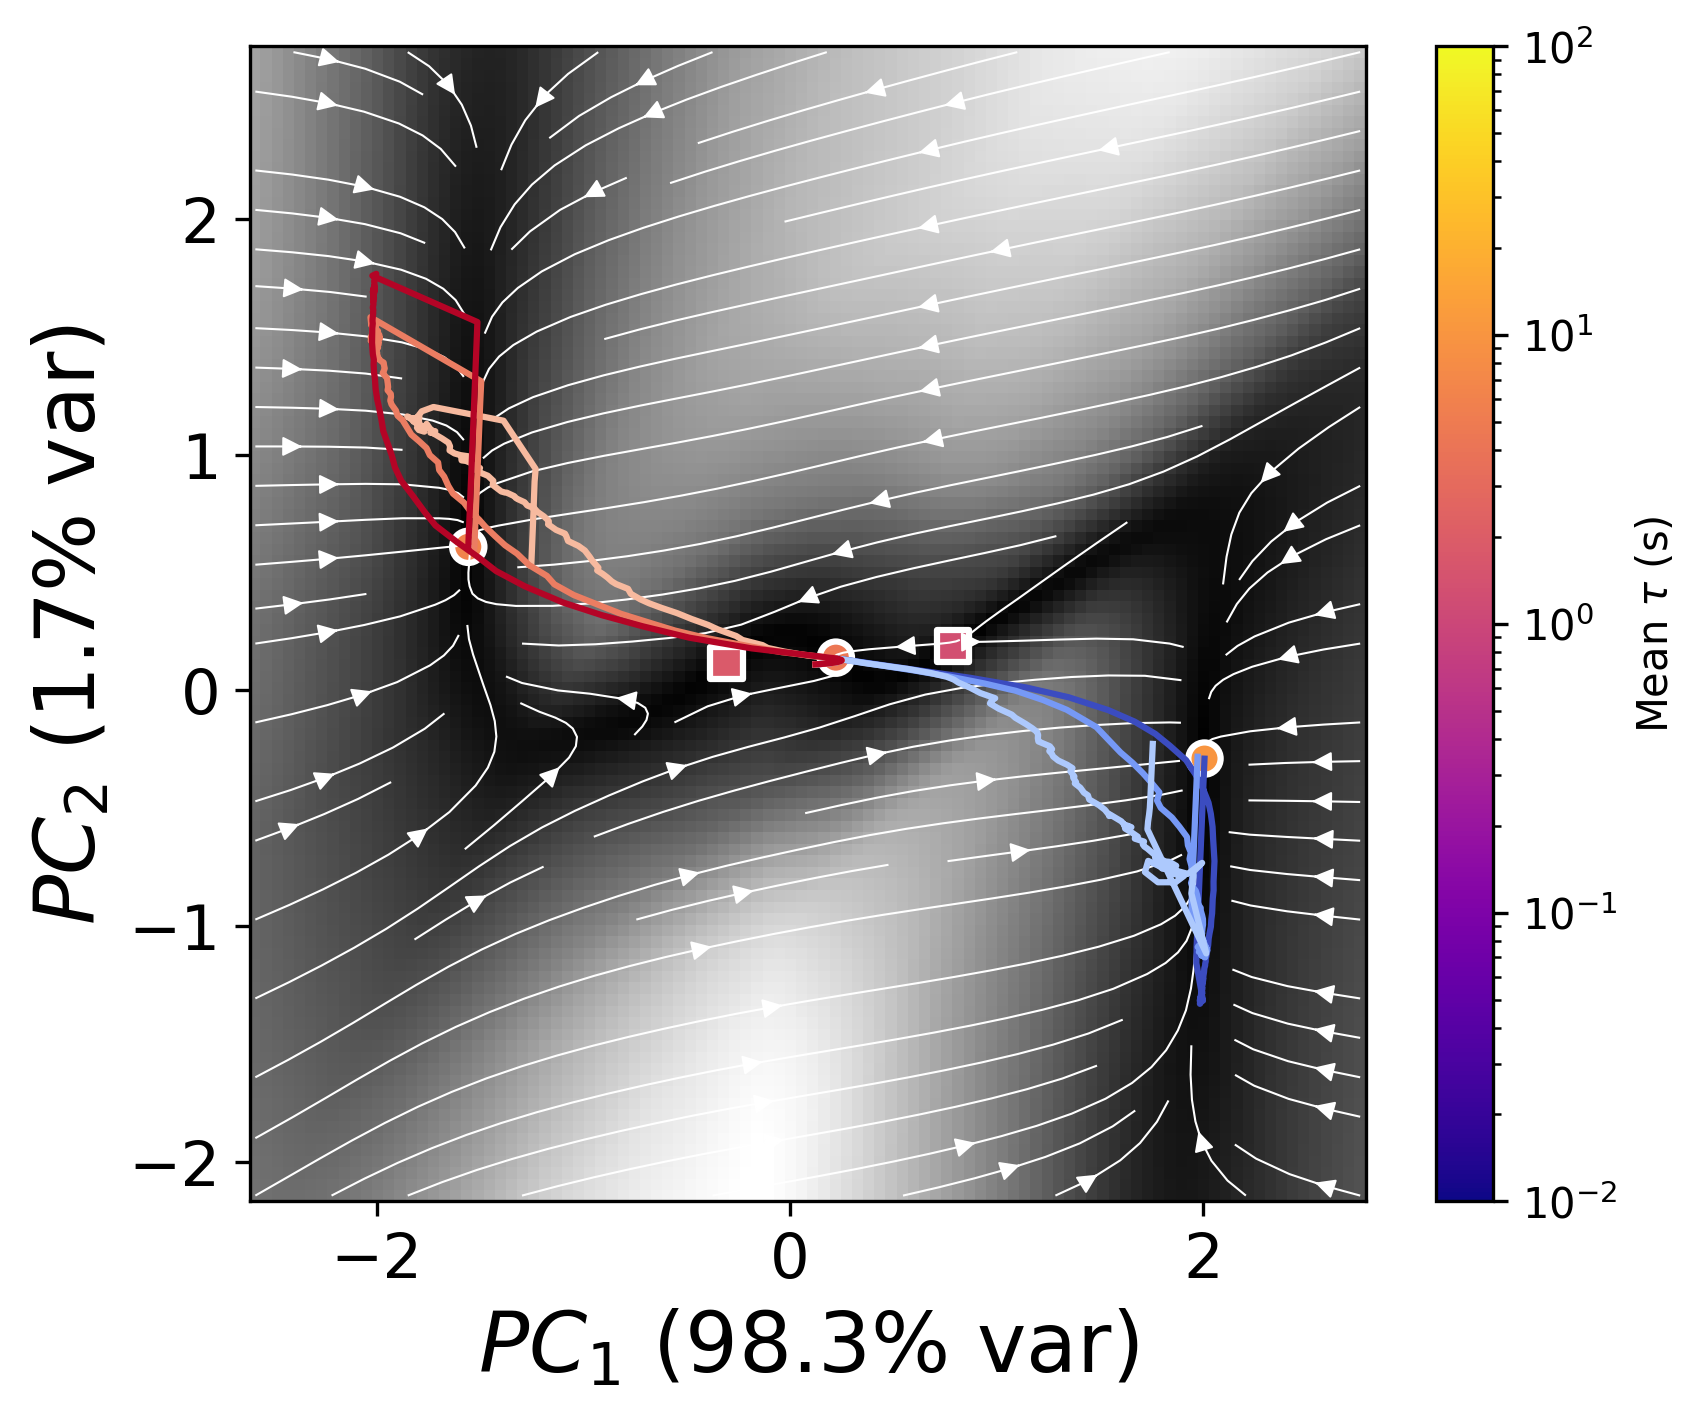

In [188]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

with open("/scratch/gpfs/ad2002/fixed_points/fps_node_tt_000.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    
cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.05)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])
    
fig, ax, PCA_NODE, explained_variance = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([0,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=False,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="all",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-2,
                    t_max=1e2,
                    return_pca=True,
                    pca_obj=PCA_GNODE,
                            
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)


[-0.782312  1.725377] -34.097470294400075
[ 0.64676267 -1.3881078 ] -18.016525932701985
[ 0.9566788 -1.6272641] -69.85102950159347
[ 0.39706722 -0.9409264 ] 30.088496153349894
[-1.4972748  1.7021357] 11.368083131518157
[ 1.6385443 -1.7206872] 15.73419225160267
[-0.04920777  0.18491016] nan
[ 0.16612063 -0.5020785 ] -8.952694058017007
/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase ave

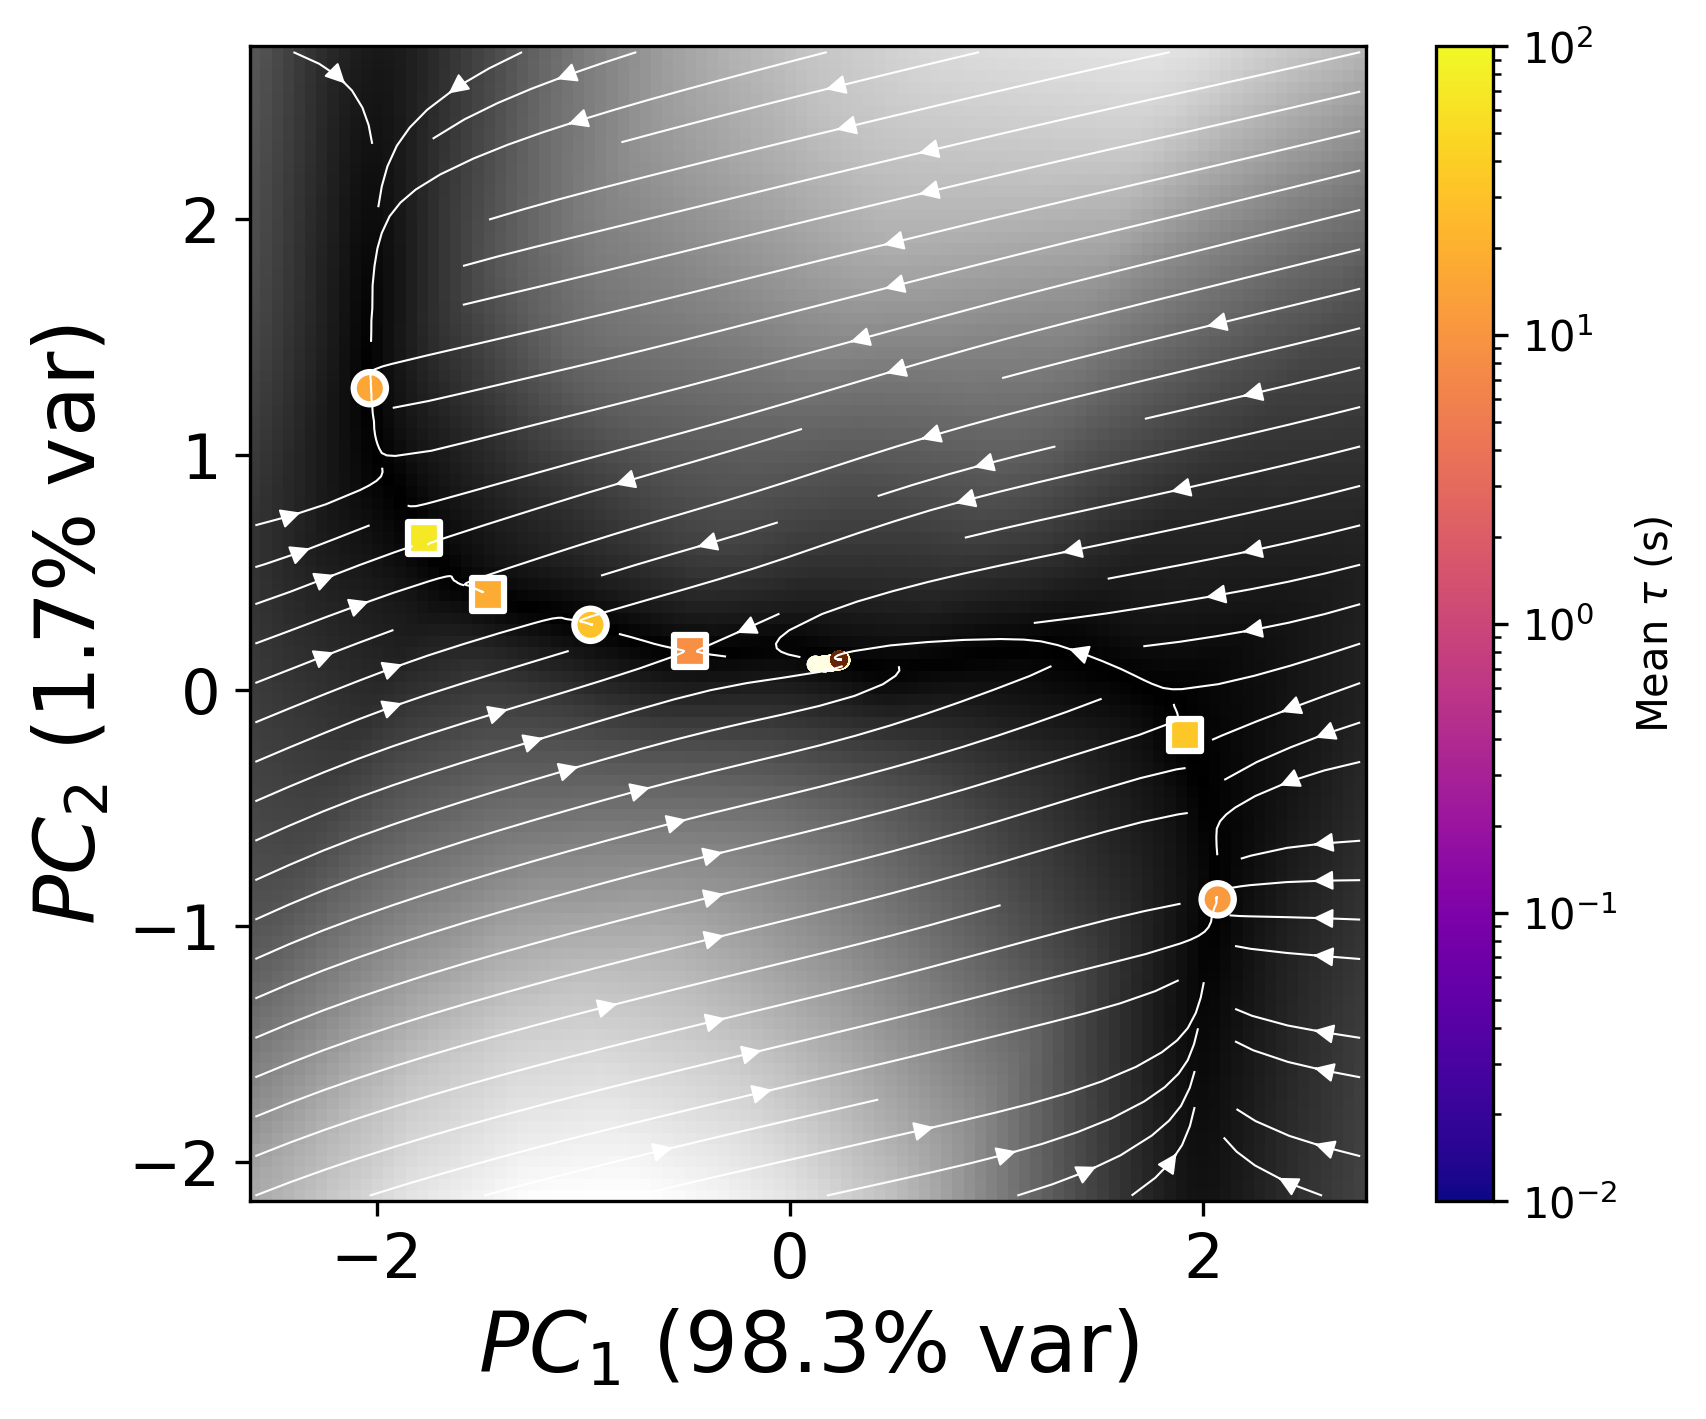

In [189]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

with open("/scratch/gpfs/ad2002/fixed_points/fps_node_tt_100.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    
cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.05)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])
    
fig, ax, PCA_NODE, explained_variance = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="delay",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-2,
                    t_max=1e2,
                    return_pca=True,
                                                           pca_obj=PCA_GNODE,
                                                           
                            
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)


[ 2.6560564 -1.3768619] 7.904868016972816
/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 92 fixed points


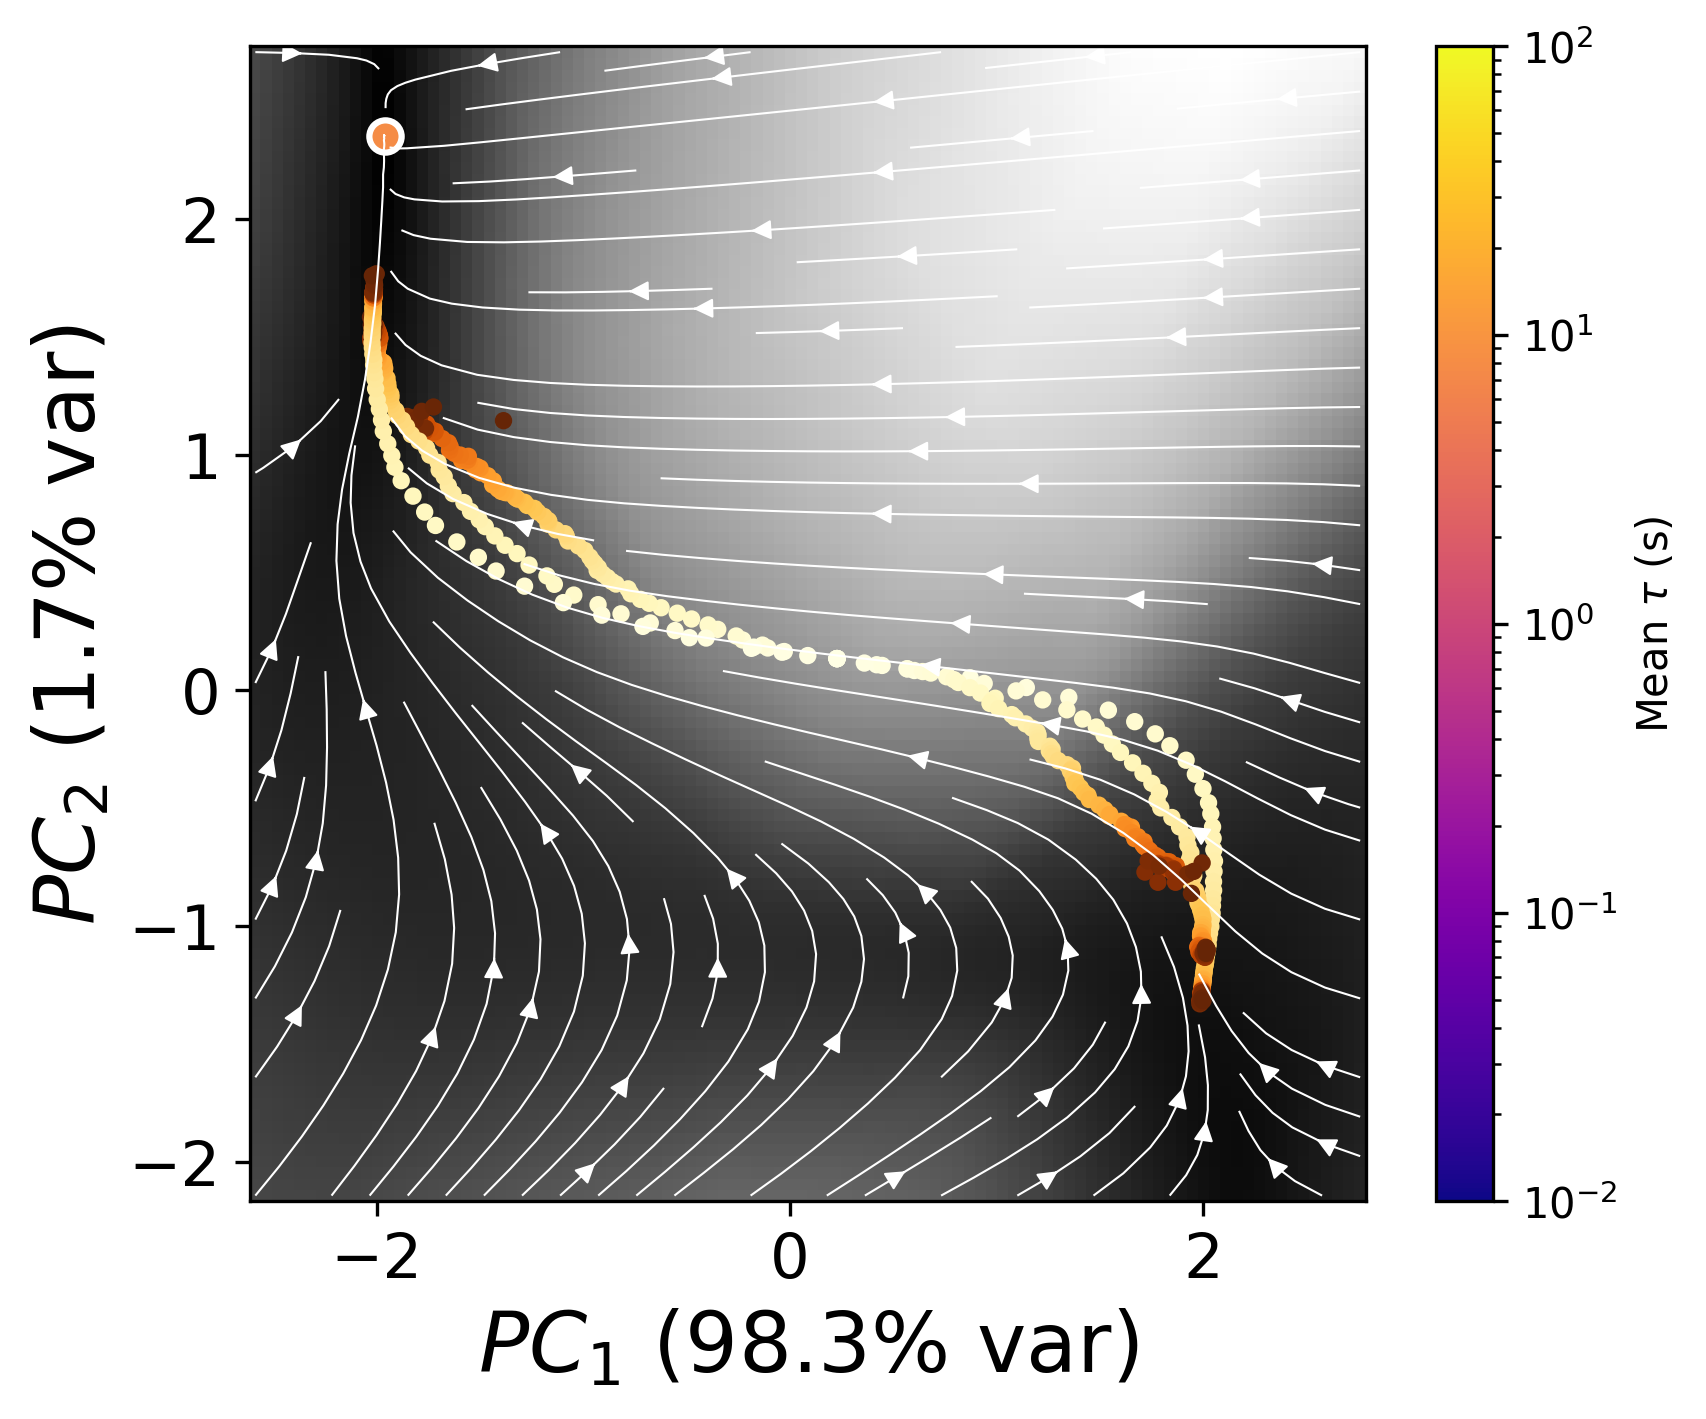

In [191]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

with open("/scratch/gpfs/ad2002/fixed_points/fps_node_tt_110.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    
cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.05)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])
    
fig, ax, PCA_NODE, explained_variance = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,1,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="stim",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-2,
                    t_max=1e2,
                    return_pca=True,
                                                           pca_obj=PCA_GNODE,
                            
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)


[ 0.07465062 -0.3450412 ] -1.8364056102918553
[-0.03788838  0.17301023] 4.4750358784316155
[-0.13428466  0.7357698 ] -1.3001889070527899
[ 0.8668416 -1.4298016] 6.075554085004026
[-0.9032198  1.7914507] 10.193934641083883
/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 586 fixed points


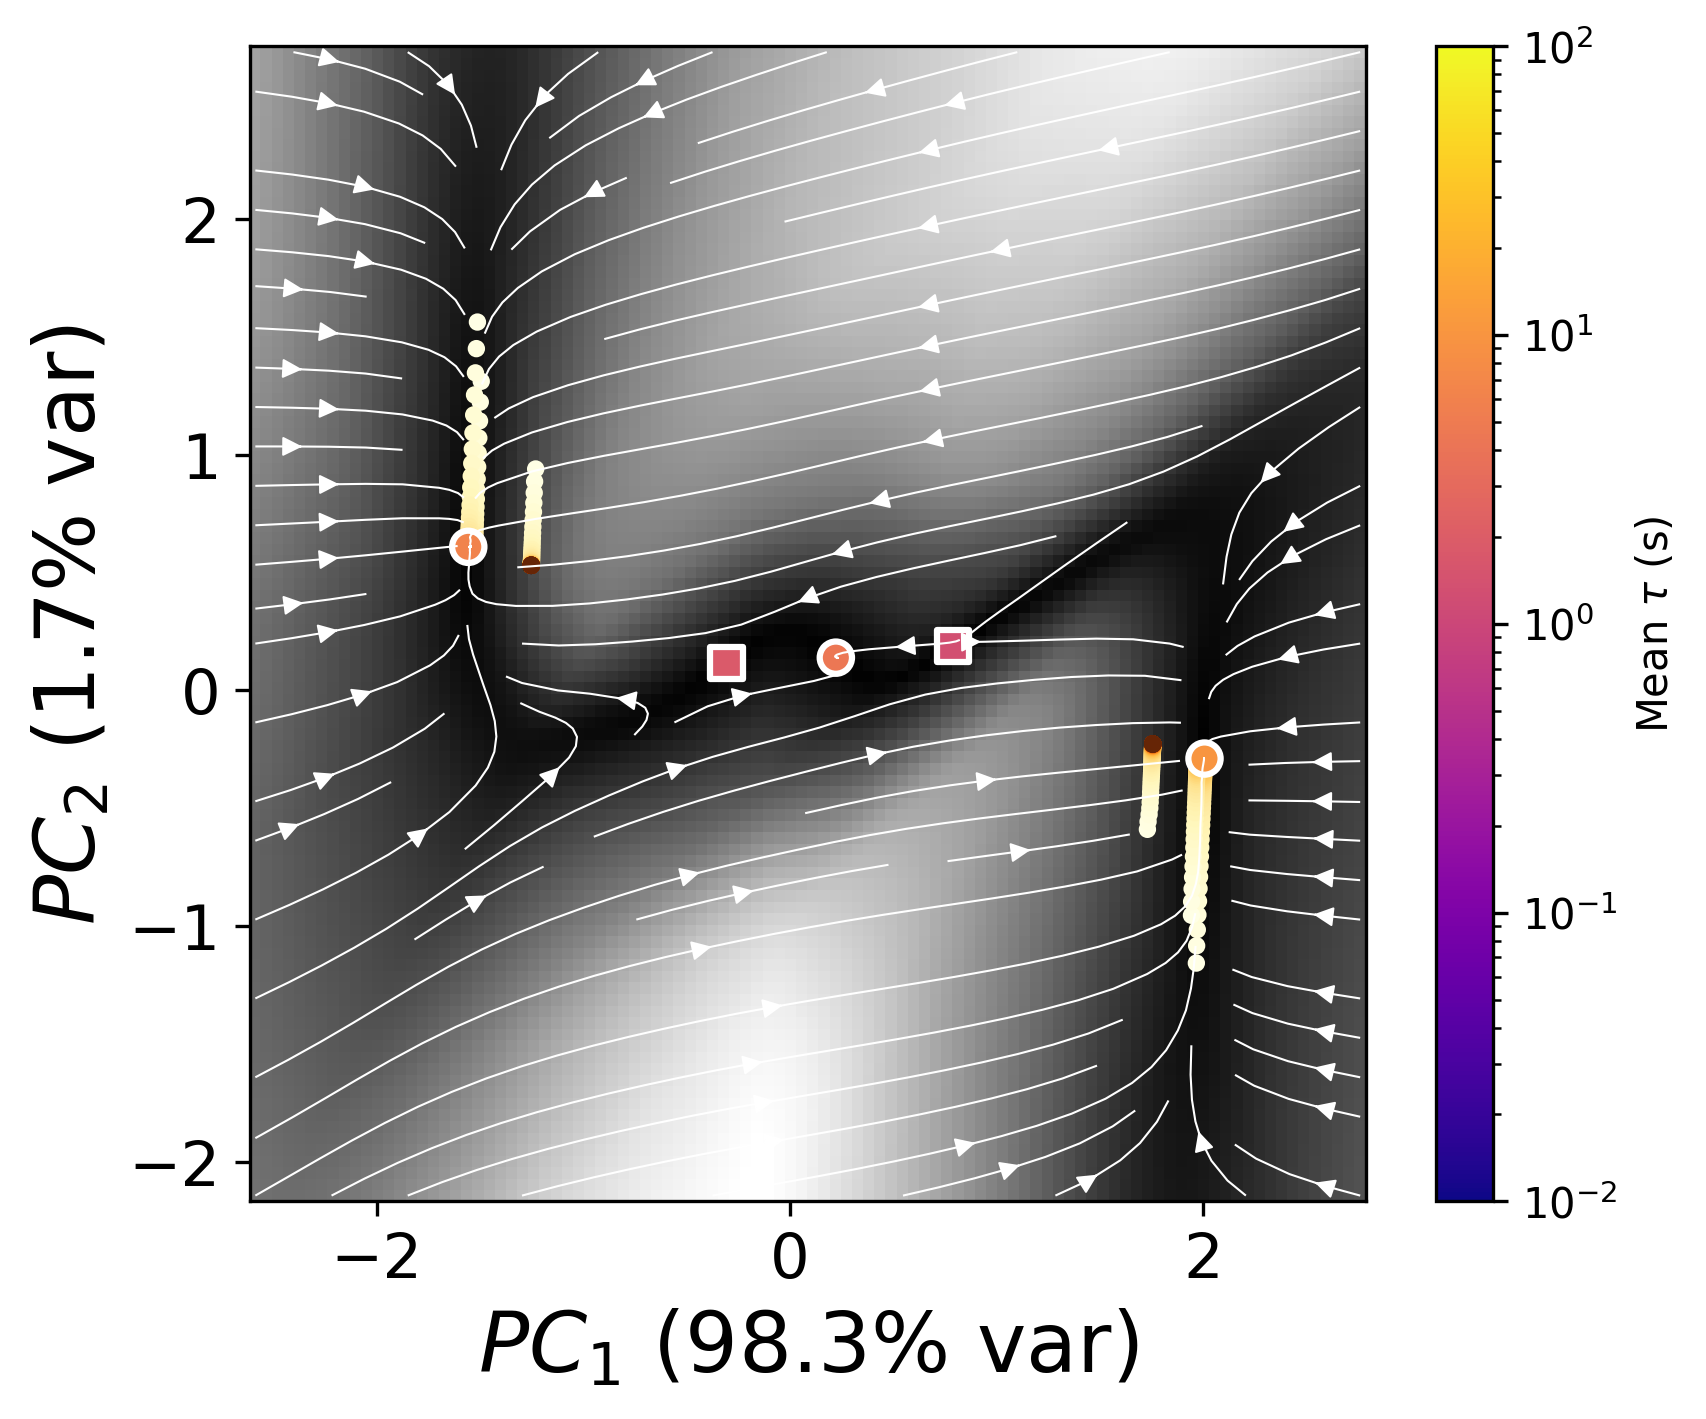

In [192]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

with open("/scratch/gpfs/ad2002/fixed_points/fps_node_tt_000.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    
cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.05)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])
    
fig, ax, PCA_NODE, explained_variance = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([0,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="resp",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-2,
                    t_max=1e2,
                    return_pca=True,
                                                           pca_obj=PCA_GNODE,
                            
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)


# GNODES all fps done

[1.3566121 0.6832663] 7.506483642909799
[-0.12780744  0.01643562] 133.90863931936502
[-0.90858126 -0.24031772] -6.698380480342738
[0.8579457  0.23930676] -4.601858450268333
[-1.6218729  -0.85596246] 16.234180204077724
/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True
loss:  0.0069489264860749245
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 68 fixed points


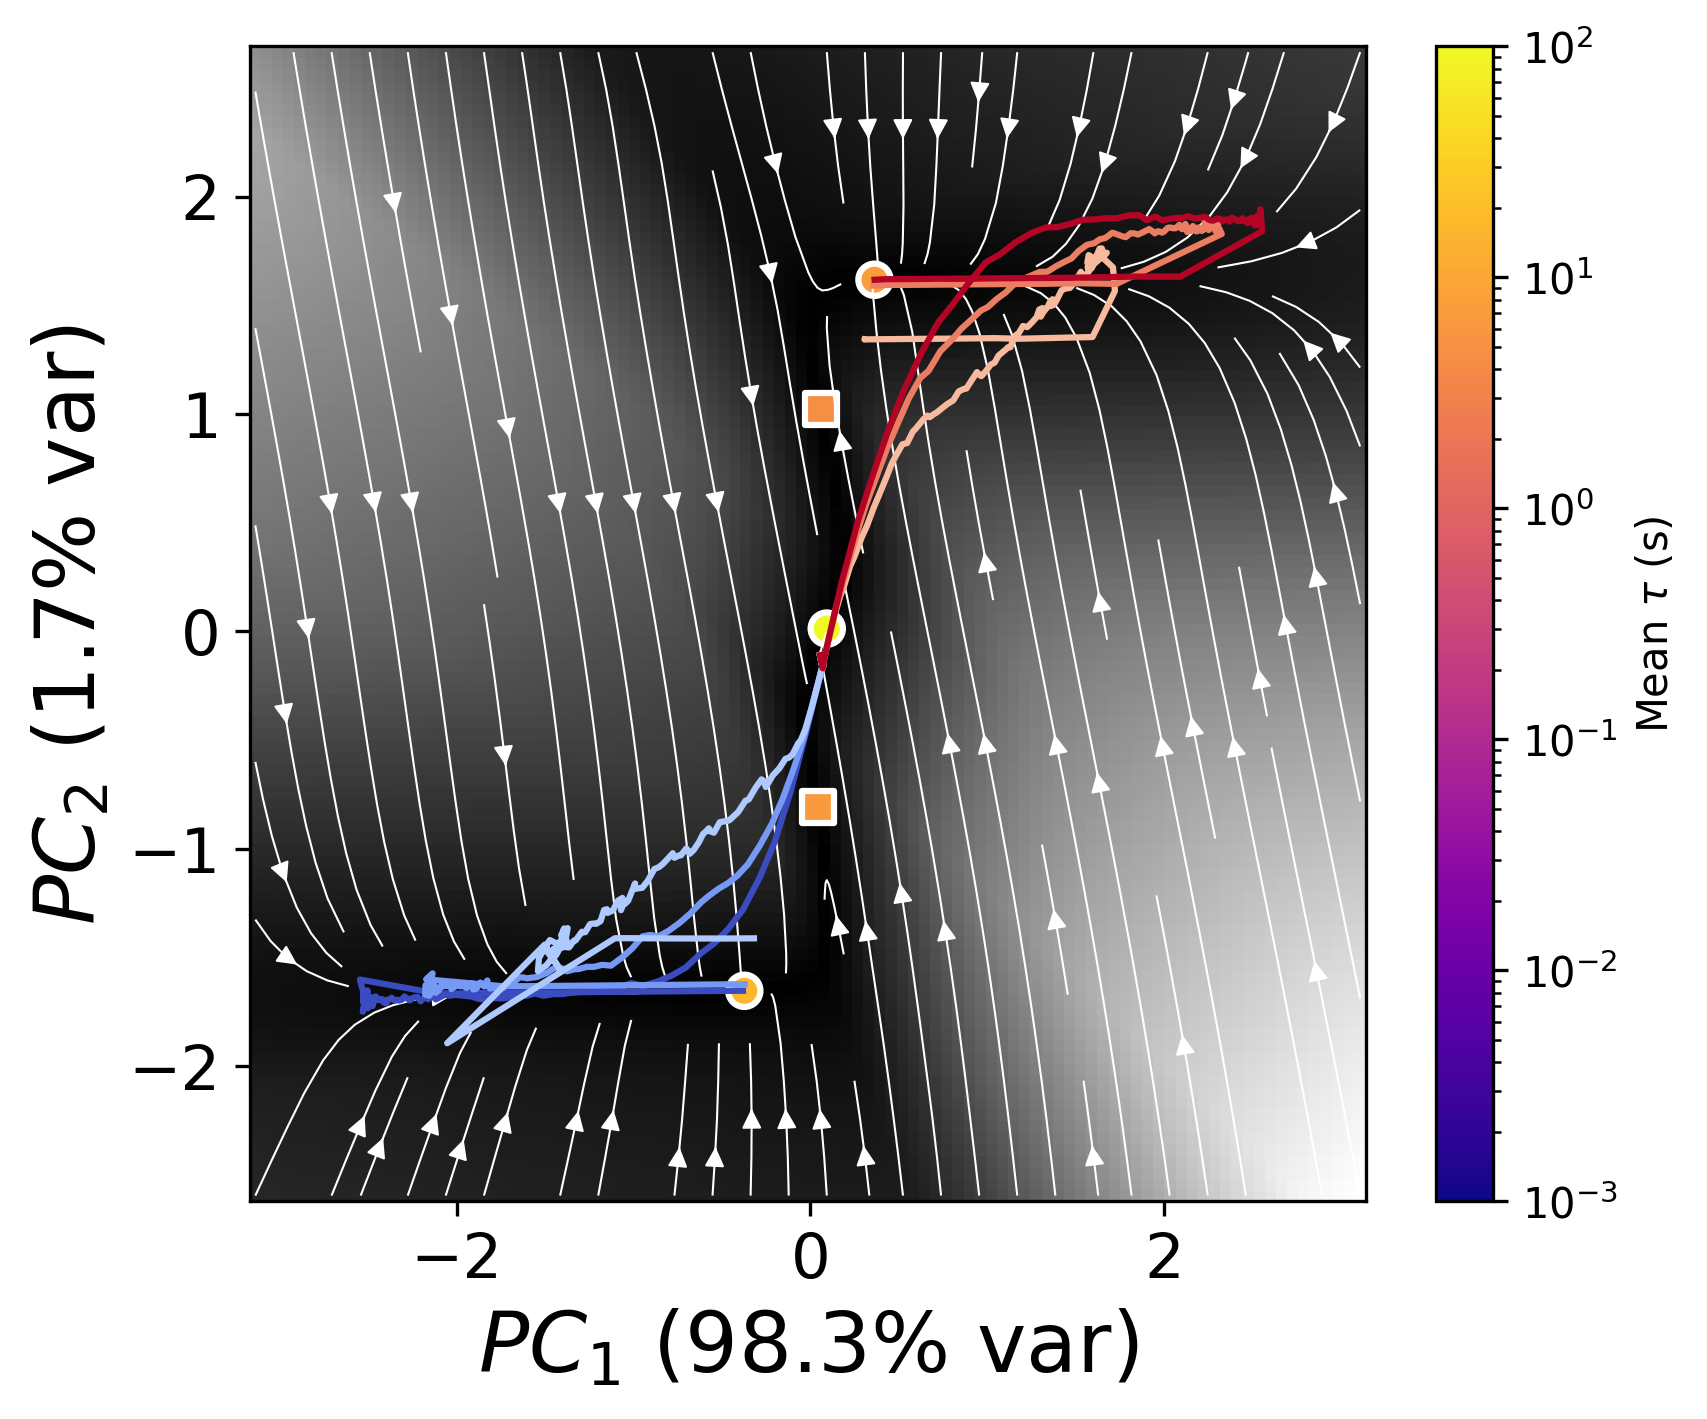

In [207]:
# this is the lowest mse that is CORRECT that i did n to
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"


# TEMPORARILY try the "right shape" to see if timescales change
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"



with open("/scratch/gpfs/ad2002/fixed_points/fps_gnode_tt_000.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-9]
    

cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.1)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])

    
fig, ax, PCA_GNODE, var= analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([0,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=1000,
                    scatter=False,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="all",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-3,
                    t_max=1e2,
                    pca_obj=PCA_NODE,
                    return_pca=True,
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)

[1.2731674  0.97529525] -891.3907390855119
[0.03809209 0.15769215] 3438.2694140340996
[-1.0295316 -0.5561332] -374.47666215508167
[1.3162258 1.7539614] 361.09268655604217
[-1.2645266 -1.5460819] 687.2099153221964
/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True
loss:  0.0069489264860749245
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 34 fixed points


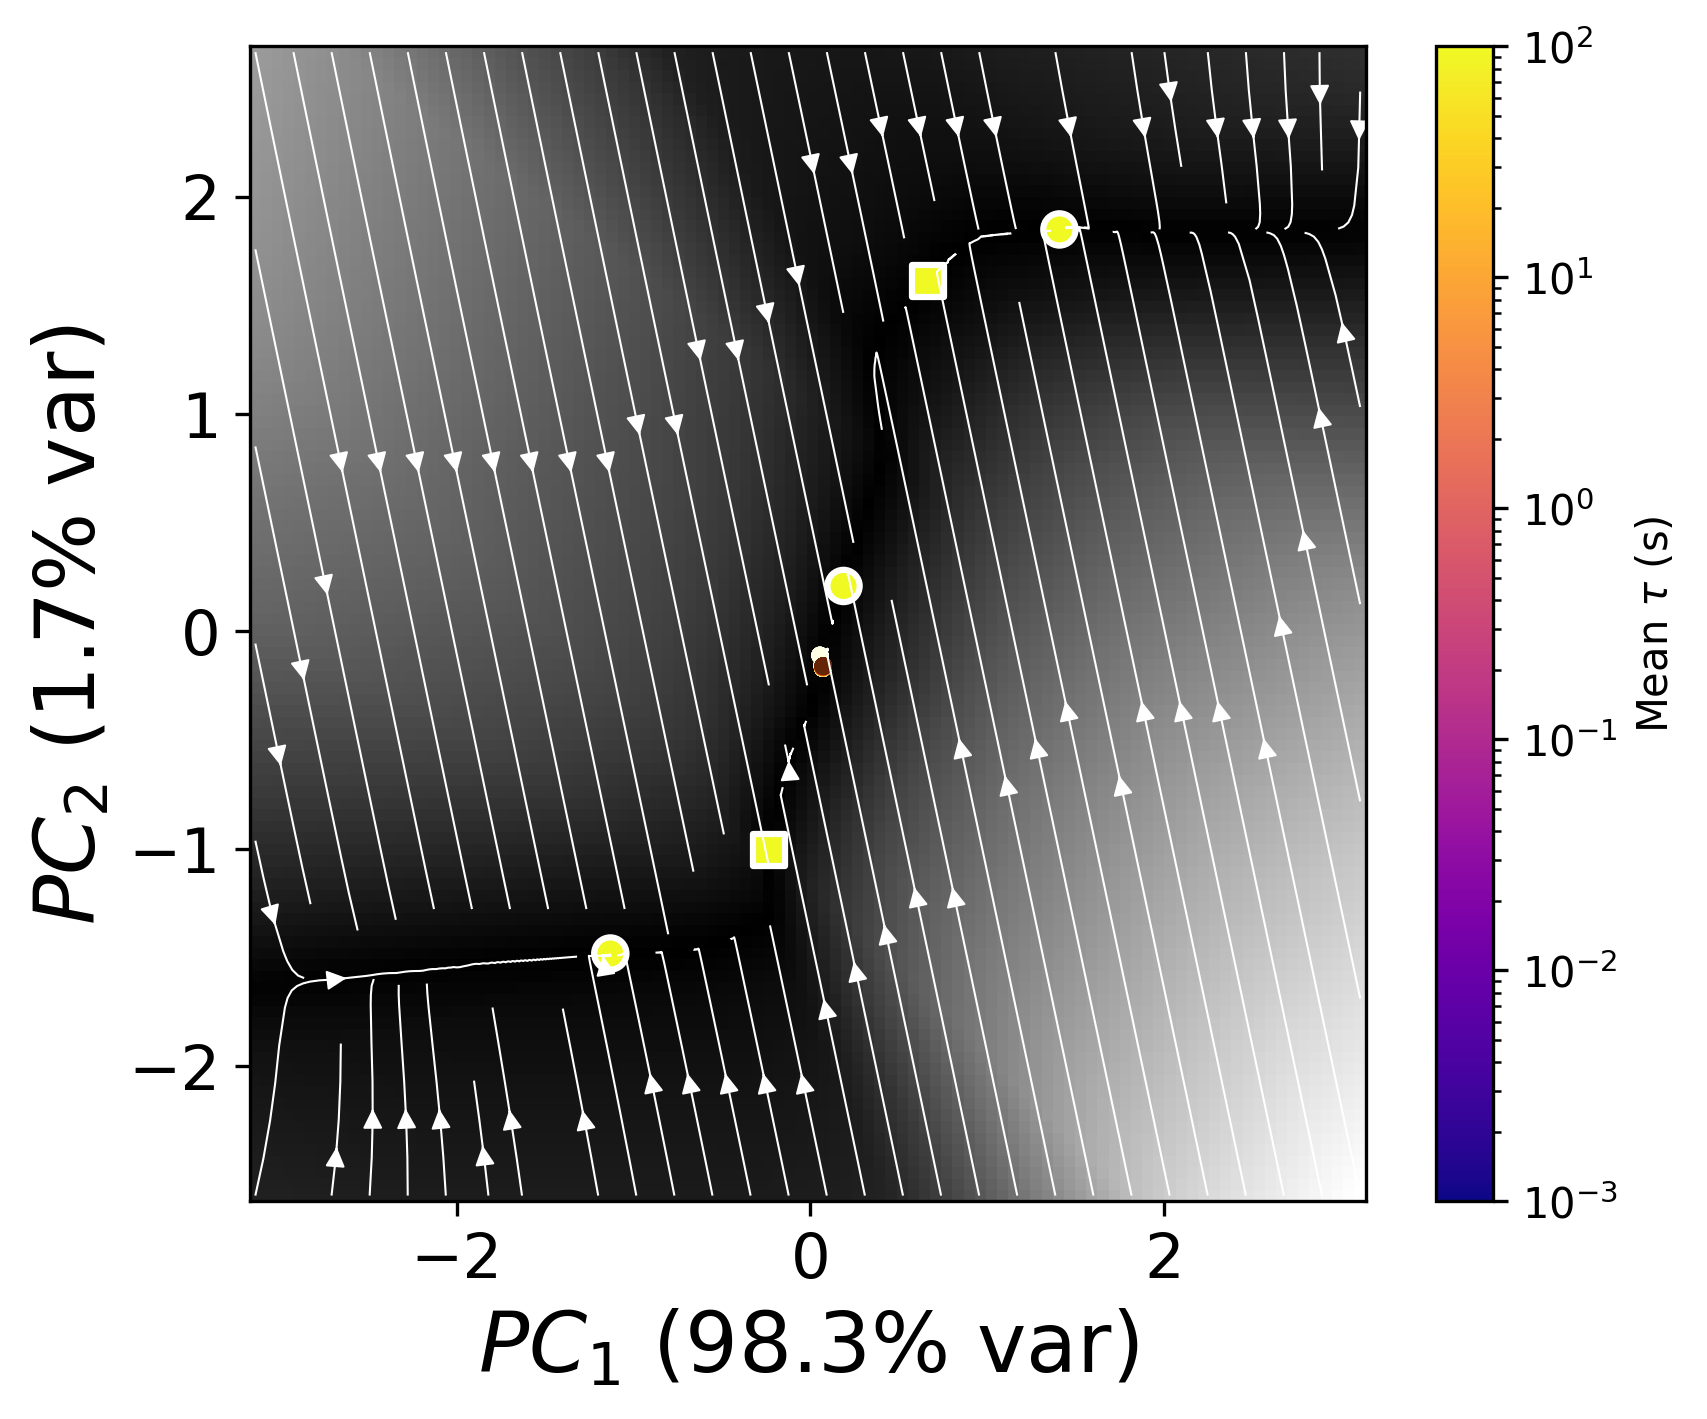

In [215]:
# this is the lowest mse that is CORRECT that i did n to
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"


# TEMPORARILY try the "right shape" to see if timescales change
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"



with open("/scratch/gpfs/ad2002/fixed_points/fps_gnode_tt_100.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-11]
    

cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.1)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])

    
fig, ax = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=1000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="delay",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-3,
                    t_max=1e2,
                    pca_obj = PCA_NODE,
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)

[-8.718949   6.5023055] -10781.029284278675
[ -4.7984586 -13.182357 ] -26448.7838713913
[-10.332936    7.3230257] -51285.40182246118
[ -5.29946  -14.211122] -55209.27875476878
[-12.124344   8.207235] -292594.75937069074
[ -8.870272 -21.559076] -8227671.368612493
[-13.910433   9.087603] -1668309.85311445
[ -4.3343987 -12.256857 ] -13964.439160838057
[ -4.546091 -12.673058] -18581.704912281843
[ -5.6234703 -14.880713 ] -89203.1075118881
[ -6.3190484 -16.309738 ] -252897.09766335797
[-8.602571   6.4423137] -9658.487096670868
[-9.999535   7.1577687] -36902.18322112664
[ -4.2006793 -11.994598 ] -11696.532659352733
[ -5.691715 -15.02227 ] -98208.82651434003
[-10.933371   7.620001] -90800.12362225466
[-9.066563   6.6816444] -14999.993239046926
[-12.26046    8.274275] -332584.48911004676
[-13.270294   8.772092] -855292.010339754
[-11.638362   7.967577] -180088.95265740177
[ -5.139886 -13.88186 ] -43450.01708971865
[-9.555114   6.9314017] -24002.485317144885
[-8.83568    6.5625825] -12049.28687

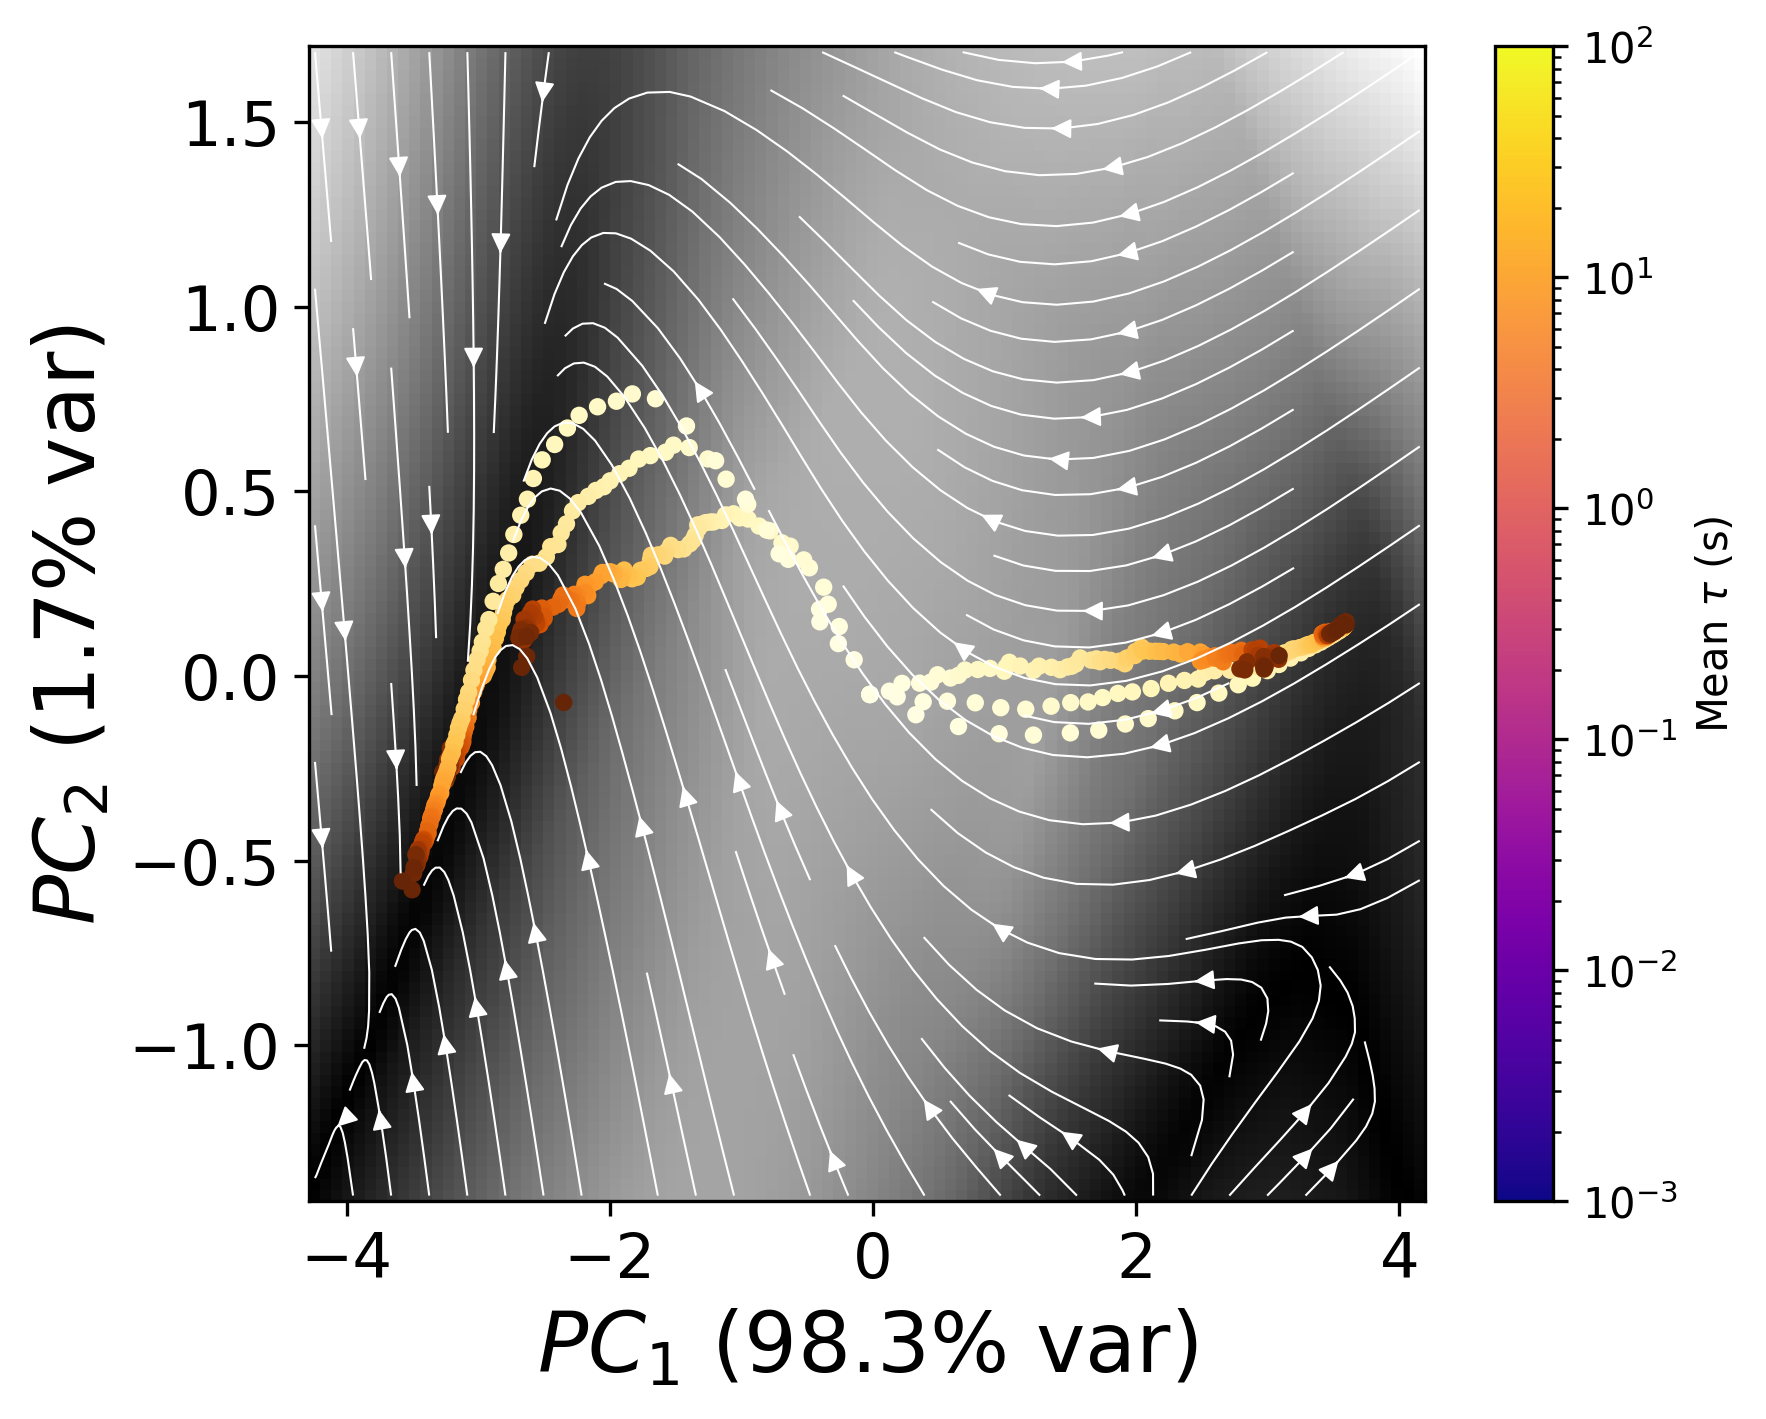

In [220]:
# this is the lowest mse that is CORRECT that i did n to
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"


# TEMPORARILY try the "right shape" to see if timescales change
#path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"



with open("/scratch/gpfs/ad2002/fixed_points/fps_gnode2_tt_110.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    

cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.1)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])

    
fig, ax = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,1,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=1000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="stim",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-3,
                    t_max=1e2,
                    pca_obj = PCA_NODE,
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)

[ 0.5483265  -0.23618864] -4.127643035018299
[ -3.7789345 -11.457304 ] -10876.864448012864
[-10.819278   6.799549] -45803.15656814873
[0.2104803  0.42326802] nan
[-12.717514   7.745673] -287444.59327661793
[ -4.2450743 -12.435285 ] -21983.625716688504
[ -4.8894787 -13.784634 ] -59363.97263318763
[-15.031373   8.899423] -2710832.232950301
[ -4.3098583 -12.571003 ] -24296.333701294956
[ -4.6616063 -13.307401 ] -41725.52088290325
[-0.03495541  0.82438135] -2.808171651172607
[ -4.015219 -11.954064] -15520.155076586427
[-9.224088  6.004549] -9944.951049845393
[-10.368661    6.5749907] -29638.375338066497
[-9.724735  6.254118] -16021.553989822489
[-13.084078    7.9282417] -430704.0416502082
[ -5.3212185 -14.689698 ] -115285.94364668484
[ -4.975425 -13.96459 ] -67657.72043958586
[ -3.9275563 -11.770535 ] -13615.583881935241
[ -3.7043006 -11.300056 ] -9719.4831785373
[ -4.164471  -12.2664385] -19462.344471977765
[-10.606711   6.693609] -37340.52731409559
[-11.881344    7.3289165] -129009.09122

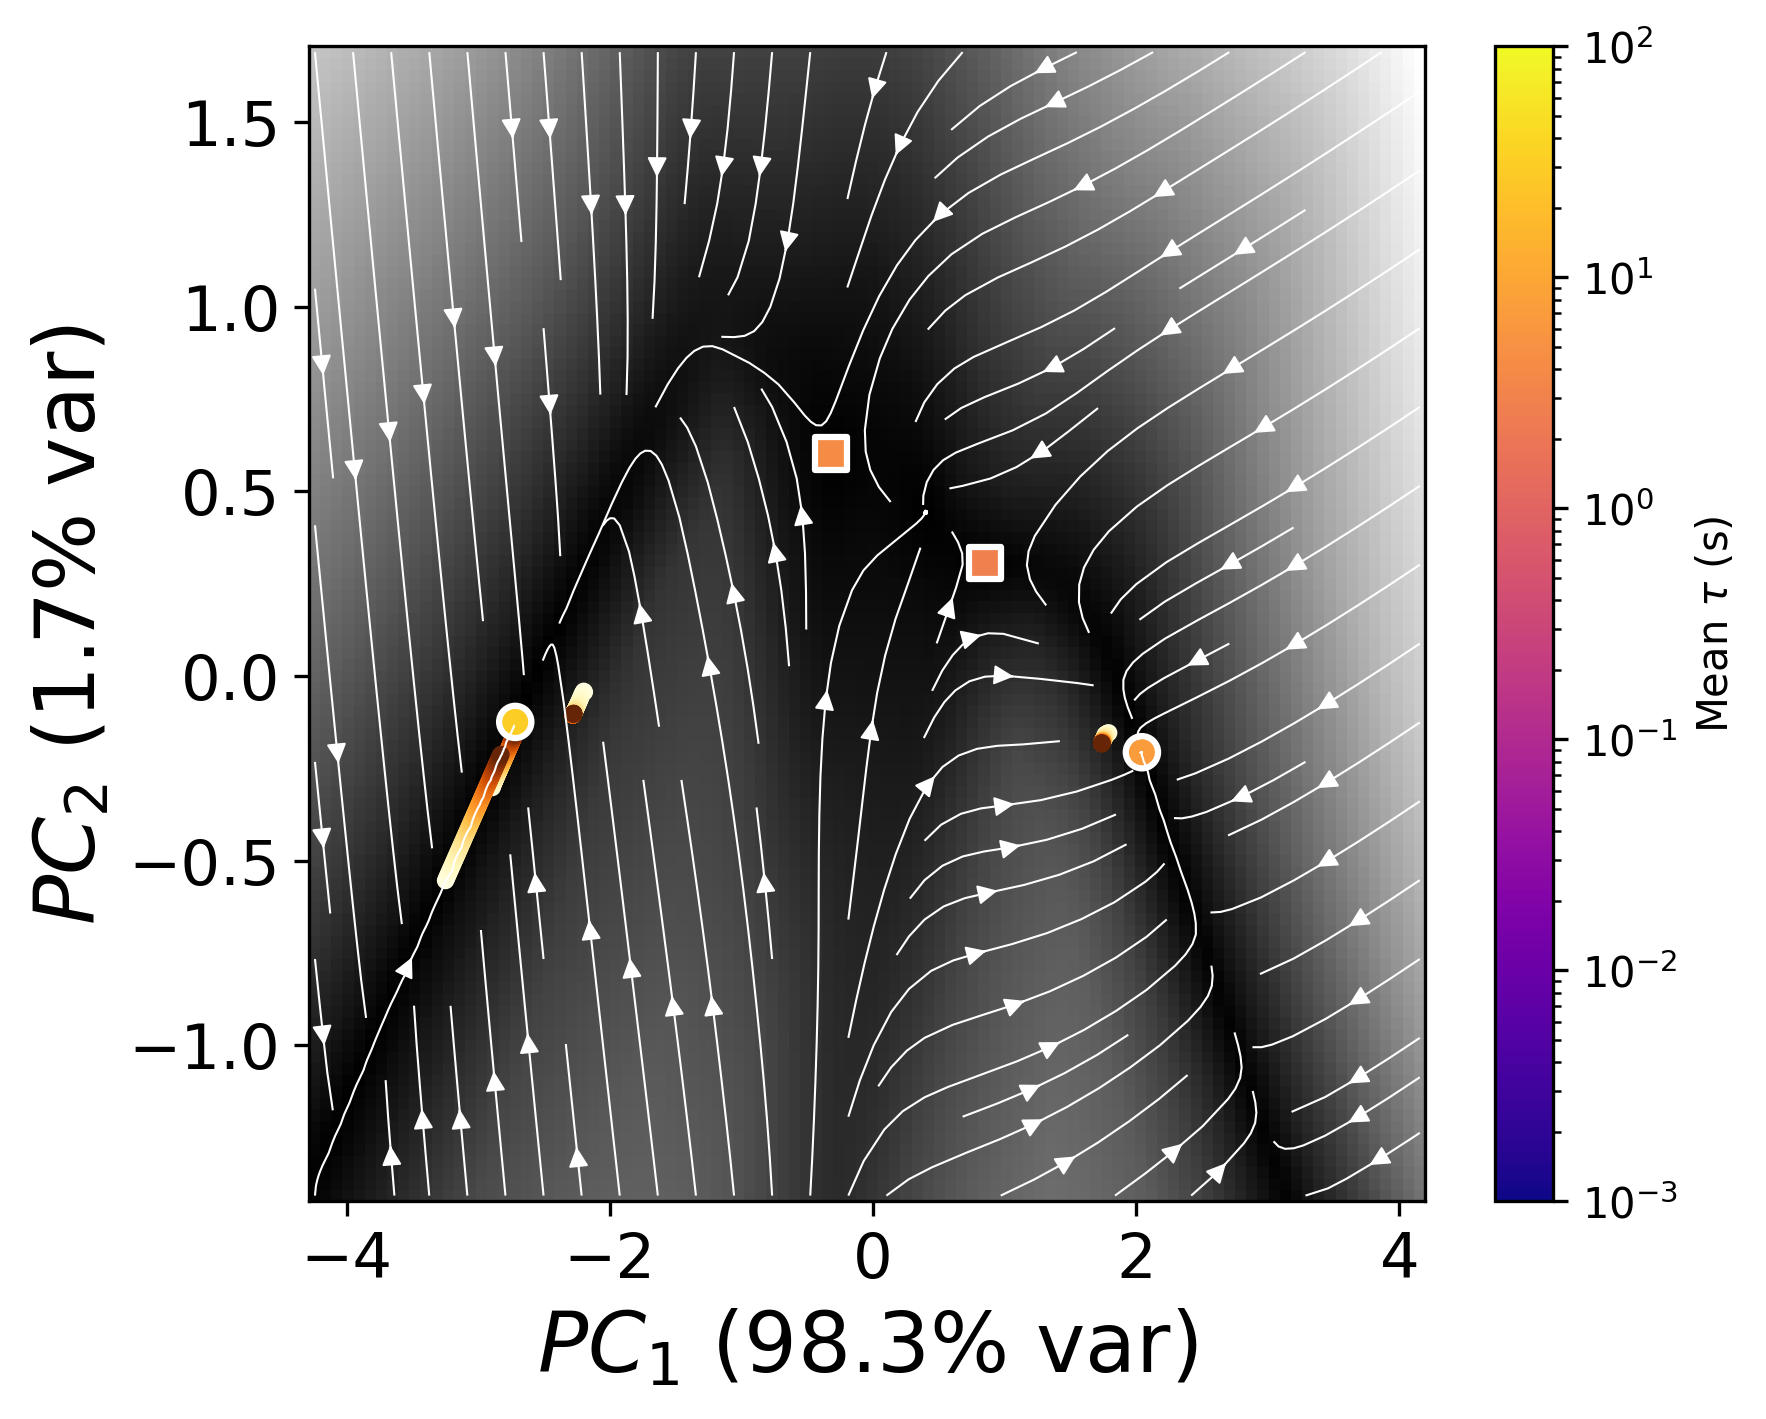

In [218]:
# this is the lowest mse that is CORRECT that i did n to
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"


# TEMPORARILY try the "right shape" to see if timescales change
#path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"



with open("/scratch/gpfs/ad2002/fixed_points/fps_gnode2_tt_000.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    

cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.1)
for i,c in enumerate(cluster_centers):
    print(c, timescales[i])

    
fig, ax = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([0,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=1000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]],
                    pca=True,
                    koopman=True,
                    task_loss_func=pc_loss_func,
                    phase="resp",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                    ortho_koopman=True,
                    timescales=timescales,
                    cluster_centers=cluster_centers,
                    cluster_is_stable=cluster_is_stable,
                    t_min=1e-3,
                    t_max=1e2,
                    pca_obj = PCA_NODE,
                 )

fig.set_dpi(300)
fig.set_size_inches(6, 5)

## nGRUs - FPs all calculated

Supposed to be a model of high capacity - but can only visualize trajs in dim 2

PCA explained variance: PC1=0.8292 PC2=0.1501
Total variance explained: 0.9792
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 2026 fixed points


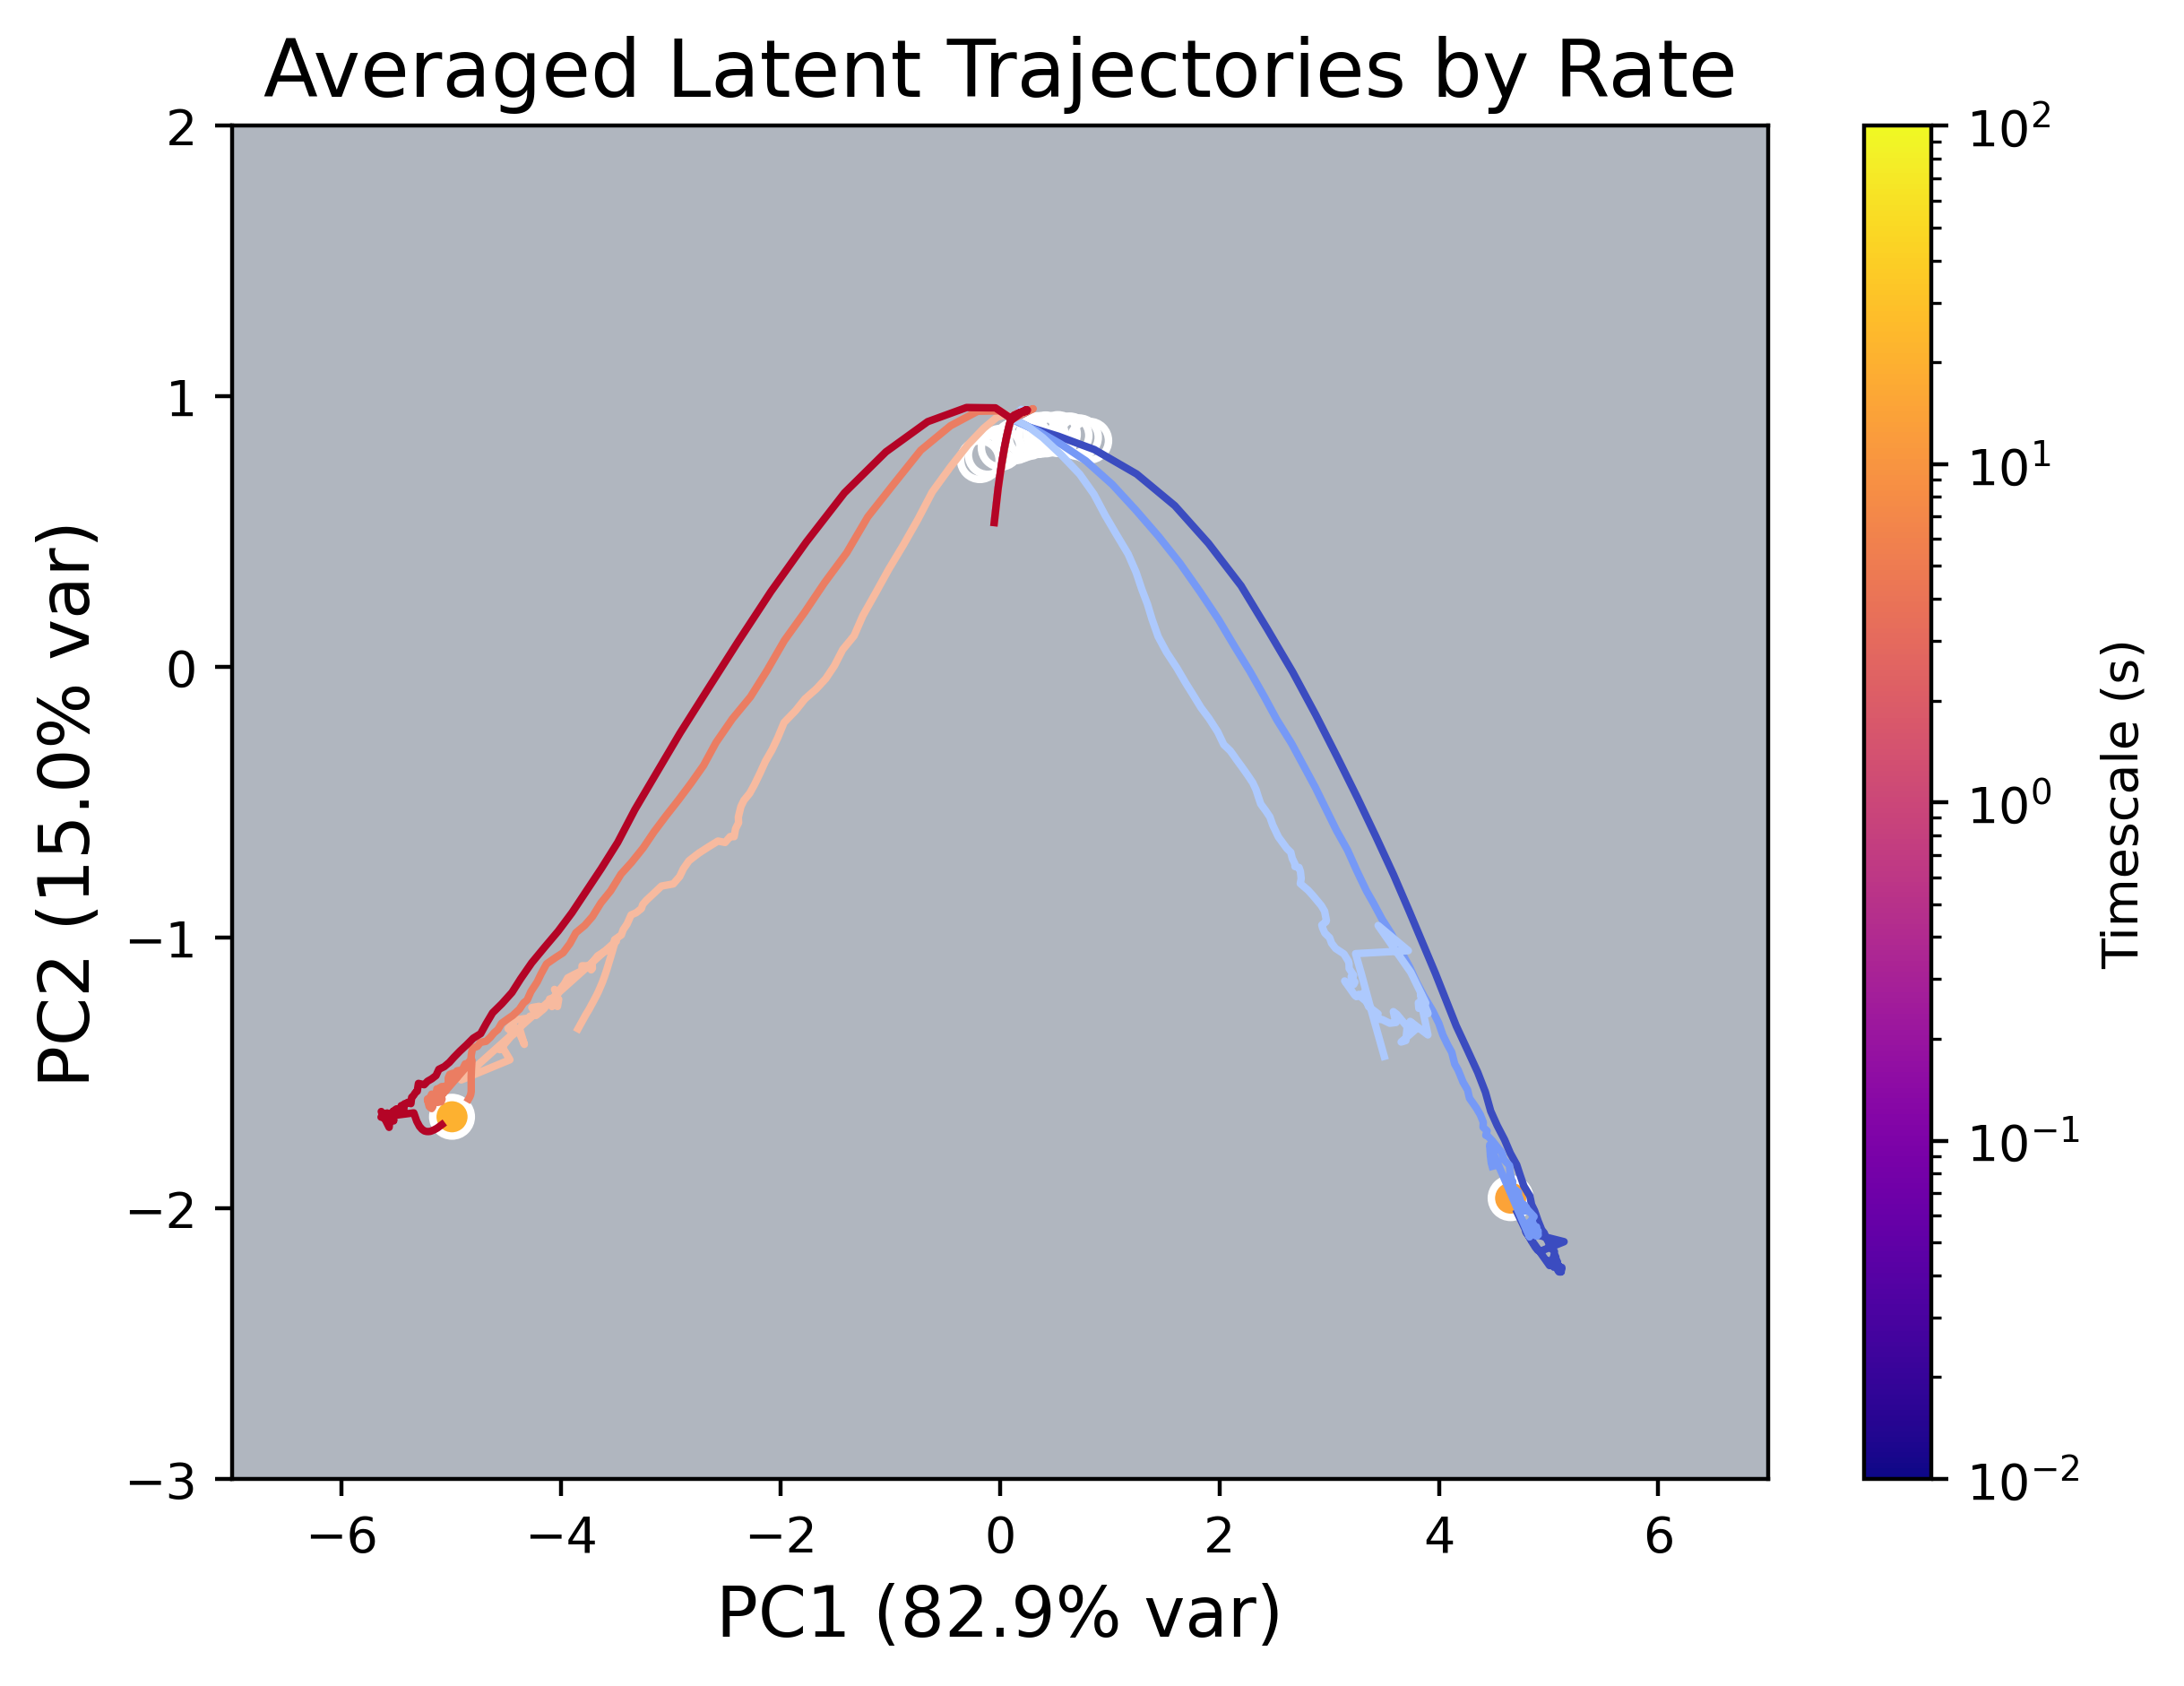

In [249]:
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2"
tune_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
task_dataset_dict=d1e2

intrinsic=False

inputs_latents = task_dataset_dict["inputs"]
        
if intrinsic:
    inputs_latents = np.zeros_like(inputs_latents)


with open("/scratch/gpfs/ad2002/fixed_points/fps_gru_tt_000.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-5]
    
cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 1.0)
# for i,c in enumerate(cluster_centers):
#     print(c, timescales[i])
    

gru_pc = Analysis_TT(run_name = "gru_pc", filepath = tune_dir + "/")
fig,ax = plot_trial_latents_new(gru_pc, num_trials=2000, 
                                    pca=True, 
                                    n_components=2, 
                                    avg_per_rate=True,
                                    xstar=fps.xstar, 
                                    is_stable=fps.is_stable, 
                                    phase="all", 
                                    inputs_latents=inputs_latents,
                                    plot_wrapper_trajs=False, 
                                    input_latents_extra=task_dataset_dict["extra"],
                                    scatter_trajectories=False,
                                    timescales=timescales,
                                    cluster_centers=cluster_centers,
                                    cluster_is_stable=cluster_is_stable,
                                    t_min=1e-2,
                                    t_max=1e2,
                                    pca_obj = PCA_NODE,
                                    timescale_cmap=plt.get_cmap("plasma")
                                   )
ax.set_xlim([-7,7])
ax.set_ylim([-3,2])
fig.set_dpi(400)

## TT - NODE - grid all flow fields size=2 w/ params

* runs also with size=2,3,5,10 but NOT visualized here (see below for trajs)
* here with dt in sec, before dt=tau (TO-DO: which one is better?)

In [240]:
    def plot_trial_latents_new(self, num_trials=10, pca=False, n_components=2, avg_per_rate=True,
                               xstar=None, is_stable=None, phase="all", inputs_latents=None,
                               plot_wrapper_trajs=False, input_latents_extra=None, scatter_trajectories=False,
                               timescales=None, cluster_centers=None, cluster_is_stable=None, t_min=5.0, t_max=10.0,
                              timescale_cmap=None, pca_obj=None):
        """
        Plot latent trajectories for trials ran during training, with
        predetermined train/val inputs.
        """
        
        tt_ics, correct_inputs, _ = self.get_model_inputs(phase='all')
        if inputs_latents.shape[-1] != correct_inputs.shape[-1]: 
            raise ValueError("inputs_latents should have last dimension: ", correct_inputs.shape[-1])
        else:
            inputs_latents = torch.tensor(inputs_latents, dtype=torch.float32)  #from numpy to tensor

        # get the latents for as many trials as in inputs_latents
        inputs_to_env = self.get_inputs_to_env(phase="all")  # TODO: is inputs_to_env, tt_ics an issue?
        # same number of trials
        n, t, _ = inputs_latents.shape
        tt_ics = tt_ics[:n]
        inputs_to_env = inputs_to_env[:n]
        
        if plot_wrapper_trajs:
            latents = self.get_latents().detach().numpy()
            labels = self.get_extra_inputs().detach().numpy()
        else:
            # run inference 
            out_dict = self.wrapper(tt_ics, inputs_latents, inputs_to_env, custom_n_timesteps=None)
            latents = out_dict["latents"].detach().numpy()
            if input_latents_extra is not None:
                labels = input_latents_extra

        # Check if the latent dimension is at least equal to n_components
        if latents.shape[-1] < n_components:
            raise ValueError(f"Latent dimension ({latents.shape[-1]}) must be at least equal to n_components ({n_components}).")

        # Apply PCA if specified
        if pca:
            B, T, N = latents.shape
            latents_flat = latents.reshape(-1, N)
            if pca_obj is None:
                pca_model = PCA(n_components=n_components)
                pca_model.fit(latents_flat)
            else:
                pca_model = pca_obj
            latents_pca = pca_model.transform(latents_flat)
            latents_pca = latents_pca.reshape(B, T, n_components)

            # Get explained variance
            explained_variance = pca_model.explained_variance_ratio_
            print(f"PCA explained variance: {' '.join([f'PC{i+1}={var:.4f}' for i, var in enumerate(explained_variance)])}")
            print(f"Total variance explained: {np.sum(explained_variance):.4f}")

            # Use PCA transformed latents
            latents = latents_pca

        # Average latents if specified
        if avg_per_rate:
            fig, ax = plt.subplots()
            if n_components==3:
                ax = fig.add_subplot(111, projection='3d')  # Set 3D projection
                
            unique_labels = np.unique(labels[:, 1])
            for i, label in enumerate(unique_labels):
                # Find the indices of latents with the current label
                indices = np.where(labels[:, 1] == label)[0]
                # Get the aligned average of the latents by phase
                delay, stim, resp = self.average_latents_by_phase_new(inputs_latents[indices], latents[indices])

                # if all inputs were zero (no stim - don't need phases)
                if type(delay) == int:  # if all returned zero
                    print("Plotting for all zero inputs - no phase averaging")
                    cat = np.mean(latents[indices], axis=0)
                else:  
                    print("Plotting for non-trivial inputs with phase averaging")
                    if phase == "all":
                        cat = np.concatenate((delay, stim, resp), axis=0)
                    elif phase == "delay":
                        cat = delay
                    elif phase == "stim":
                        cat = stim
                    elif phase == "resp":
                        cat = resp

                norm_labels = plt.Normalize(1,39)
                # plot all the latents for this label
                if scatter_trajectories:
                    # can color each phase different
                    c = np.linspace(0, 1, cat.shape[0])
                    ax.scatter(*cat.T, s=10, color=plt.get_cmap('YlOrBr')(c))
                else: 
                    norm_labels = plt.Normalize(1,39)
                    # concatenate to make a continuous time series and color by label
                    ax.plot(*cat.T, linewidth=1.5, color=plt.get_cmap('coolwarm')(norm_labels(label)))
 
                # # concatenate to make a continuous time series and color by label
                # ax.plot(*cat.T, linewidth=1.5, color=plt.cm.coolwarm(norm_labels(label)))

            # Set axis labels with explained variance if using PCA
            if pca:
                if n_components >= 1:
                    ax.set_xlabel(f"PC1 ({explained_variance[0]:.1%} var)", fontsize=14)
                if n_components >= 2:
                    ax.set_ylabel(f"PC2 ({explained_variance[1]:.1%} var)", fontsize=14)
                    
             # plot fixed points - especially for models w/o flow fields 
            if xstar is not None and is_stable is not None and not np.all(np.isnan(xstar)):
                print(f"Plotting {xstar.shape[0]} fixed points")
                
                if pca:
                    xstar_pca = pca_model.transform(xstar)
                    stable_points = xstar_pca[is_stable]
                    unstable_points = xstar_pca[~is_stable]
                else:
                    stable_points = xstar[is_stable]
                    unstable_points = xstar[~is_stable]
                    
                # color by timescale (only decaying modes)
                if len(timescales) > 0:
                    if pca:
                        centers = pca_model.transform(cluster_centers)
                    else:
                        centers = cluster_centers

                    stable_points = centers[cluster_is_stable]
                    unstable_points = centers[~cluster_is_stable]
                    timescales_stable = timescales[cluster_is_stable]
                    timescales_unstable = timescales[~cluster_is_stable]
                    # Color by timescale (both decaying and growing modes)
                    is_special = timescales_unstable == -1
                    is_valid_stable = ~np.isnan(timescales_stable)
                    is_valid_unstable = ~np.isnan(timescales_unstable) & ~is_special
                    # Combine all valid timescales for normalization
                    all_valid_timescales = []
                    if np.any(is_valid_stable):
                        all_valid_timescales.extend(timescales_stable[is_valid_stable])
                    if np.any(is_valid_unstable):
                        all_valid_timescales.extend(timescales_unstable[is_valid_unstable])
                    if len(all_valid_timescales) > 0:
                        # Create a symmetric normalization around 0
                        norm = LogNorm(vmin=t_min, vmax=t_max)  # Replace 1e-3 with your desired minimum value
                        # Plot valid stable points with continuous colormap
                        if np.any(is_valid_stable):
                            sc_stable = ax.scatter(
                                *stable_points[is_valid_stable].T, 
                                c=timescales_stable[is_valid_stable], 
                                cmap=timescale_cmap, 
                                marker='o', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot valid unstable points with continuous colormap
                        if np.any(is_valid_unstable):
                            sc_unstable = ax.scatter(
                                *unstable_points[is_valid_unstable].T, 
                                c=-1.0*timescales_unstable[is_valid_unstable], 
                                cmap=timescale_cmap, 
                                marker='s', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot special points in black
                        if np.any(is_special):
                            ax.scatter(
                                *unstable_points[is_special].T, 
                                c='black', 
                                marker='o', 
                                s=60, 
                                edgecolor=timescale_cmap,
                                linewidth=0.5,
                                edgecolors='white', # edge color
                                linewidths=2,
                            )
                        # add the colorbar
                        if np.any(is_valid_stable) or np.any(is_valid_unstable):
                            sc = sc_stable if np.any(is_valid_stable) else sc_unstable
                            plt.colorbar(sc, ax=ax, label='Timescale (s)')
                else:
                    # Plot stable points (green circles)
                    ax.scatter(*stable_points.T, c='limegreen', marker='o')

                    # Plot unstable points (brown crosses)
                    ax.scatter(*unstable_points.T, c='red', marker='x')
            # Set the face color of the plot to a specific shade of teal
            ax.set_facecolor("#b0b6bf")  # Replace "#008080" with your teal color code

            plt.title("Averaged Latent Trajectories by Rate", fontsize=16)
            plt.tight_layout()
            
            return fig,ax

        # Determine plot type (2D or 3D)
        is_3d = n_components == 3 or (not pca and latents.shape[-1] == 3)
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d" if is_3d else None)

        # Plot latents colored by rate instead of by trial
        norm_labels = plt.Normalize(1, 39)
        for i in range(min(num_trials, latents.shape[0])):
            rate = labels[i, 1]  # Get the rate for this trial
            color = plt.cm.coolwarm(norm_labels(rate))

            if is_3d:
                ax.plot(latents[i, :, 0], latents[i, :, 1], latents[i, :, 2], 
                        color=color, linewidth=1.5, label=f"{rate} Hz" if i == 0 else "")
            else:
                ax.plot(latents[i, :, 0], latents[i, :, 1], 
                        color=color, linewidth=1.5, label=f"{rate} Hz" if i == 0 else "")
             
        # plot fixed points - especially for models w/o flow fields 
        if xstar is not None and is_stable is not None and not np.all(np.isnan(xstar)):
            print(f"Plotting {xstar.shape[0]} fixed points")
            
            if pca:
                xstar_pca = pca_model.transform(xstar)
                stable_points = xstar_pca[is_stable]
                unstable_points = xstar_pca[~is_stable]
            else:
                stable_points = xstar[is_stable]
                unstable_points = xstar[~is_stable]
                
            # color by timescale (only decaying modes)
            if len(timescales) > 0:
                if pca:
                    centers = pca_model.transform(cluster_centers)
                else:
                    centers = cluster_centers
                    
                stable_points = centers[cluster_is_stable]
                unstable_points = centers[~cluster_is_stable]
                timescales_stable = timescales[cluster_is_stable]
                timescales_unstable = timescales[~cluster_is_stable]
                # Color by timescale (both decaying and growing modes)
                is_special = timescales_unstable == -1
                is_valid_stable = ~np.isnan(timescales_stable)
                is_valid_unstable = ~np.isnan(timescales_unstable) & ~is_special
                # Combine all valid timescales for normalization
                all_valid_timescales = []
                if np.any(is_valid_stable):
                    all_valid_timescales.extend(timescales_stable[is_valid_stable])
                if np.any(is_valid_unstable):
                    all_valid_timescales.extend(timescales_unstable[is_valid_unstable])
                if len(all_valid_timescales) > 0:
                    # Create a symmetric normalization around 0
                    norm = LogNorm(vmin=t_min, vmax=t_max)  # Replace 1e-3 with your desired minimum value
                    # Plot valid stable points with continuous colormap
                    if np.any(is_valid_stable):
                        sc_stable = ax.scatter(
                            *stable_points[is_valid_stable].T, 
                            c=timescales_stable[is_valid_stable], 
                            cmap=timescale_cmap, 
                            marker='o', 
                            s=60, 
                            norm=norm, 
                            edgecolors='white', # edge color
                            linewidths=1.5
                            )

                        # Plot valid unstable points with continuous colormap
                        if np.any(is_valid_unstable):
                            sc_unstable = ax.scatter(
                                *unstable_points[is_valid_unstable].T, 
                                c=-1.0*timescales_unstable[is_valid_unstable], 
                                cmap=timescale_cmap, 
                                marker='s', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot special points in black
                        if np.any(is_special):
                            ax.scatter(
                                *unstable_points[is_special].T, 
                                c='black', 
                                marker='o', 
                                s=60, 
                                edgecolor=timescale_cmap,
                                linewidth=0.5,
                                edgecolors='white', # edge color
                                linewidths=2,
                            )
                    # add the colorbar
                    if np.any(is_valid_stable) or np.any(is_valid_unstable):
                        sc = sc_stable if np.any(is_valid_stable) else sc_unstable
                        plt.colorbar(sc, ax=ax, label='Timescale (s)')
            else:
                # Plot stable points (green circles)
                ax.scatter(*stable_points.T, c='limegreen', marker='o')
                
                # Plot unstable points (brown crosses)
                ax.scatter(*unstable_points.T, c='red', marker='x')      

        # Set axis labels with explained variance if using PCA
        if pca:
            if n_components >= 1:
                ax.set_xlabel(f"PC1 ({explained_variance[0]:.1%} var)", fontsize=14)
            if n_components >= 2:
                ax.set_ylabel(f"PC2 ({explained_variance[1]:.1%} var)", fontsize=14)
            if n_components >= 3 and is_3d:
                ax.set_zlabel(f"PC3 ({explained_variance[2]:.1%} var)", fontsize=14)
        else:
            ax.set_xlabel("$lat_1$", fontsize=14)
            ax.set_ylabel("$lat_2$", fontsize=14)
            if is_3d:
                ax.set_zlabel("$lat_3$", fontsize=14)

        # # Add colorbar for rate
        # norm = plt.Normalize(1, 39)
        # sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
        # sm.set_array([])
        # cbar = plt.colorbar(sm, ax=ax)
        # cbar.set_label('Rate (Hz)', fontsize=12)

        # Set grid color to white and adjust axis labels
        ax.tick_params(axis='both', which='major', labelsize=16)

        # Set the face color of the plot to a specific shade of teal
        ax.set_facecolor("#b0b6bf")  # Replace "#008080" with your teal color code

        plt.tight_layout()
        
        return fig